# V0 spatial-residual DNN with pad-plane alignment, module offsets, and charge-balanced daughter pT

## Side-dependent rigid alignment, tilt-like gradients, 72 local modules, and parallel training

This notebook derives a smooth three-dimensional correction field for reconstructed TPC cluster positions:

\[
\Delta r(r,\phi,z,\mathrm{side}),\qquad
r\Delta\phi(r,\phi,z,\mathrm{side}),\qquad
\Delta z(r,\phi,z,\mathrm{side}).
\]

The transverse correction is explicitly decomposed into:

\[
\Delta_T
=
u\,\Delta_T^{\mathrm{drift}}
+
(1-u)\left(
\Delta_T^{\mathrm{side\ alignment}}
+
\Delta_T^{\mathrm{local\ module}}

ight),
\]

where

\[
u = 1-

rac{|z|}{z_{
m pad}}.
\]

Therefore:

- the drift-dependent DNN contribution is largest near the central membrane and vanishes at the pad plane;
- side-level pad-plane offsets and tilt-like transverse gradients are allowed to remain nonzero at the pad plane;
- each of the 72 TPC modules (2 sides × 12 sectors × 3 radial modules) has an independent small transverse displacement;
- the two sides use independent parameters and can converge to similar but non-identical alignment values;
- \(\Delta z\), when enabled, still vanishes exactly at the pad plane.

Two geometry profiles are provided:

- `conservative`: smaller side shift/tilt and local-module limits;
- `wide`: side shift/tilt limits up to 2 cm and local-module offsets up to 300 μm.

Use separate notebook processes with different `geometry_profile_name` values to run the two profiles in parallel. Their checkpoints, caches, QA files, CSV maps, and ROOT maps are written to different directories.


## Charge-symmetry constraint

For \(K^0_S\to\pi^+\pi^-\), the corrected charge-separated daughter
\(p_T\) spectra are constrained to have the same normalized shape.
The differentiable charge-balance objective compares soft histograms,
weighted means, and weighted RMS values. It is intentionally assigned
a larger training and validation weight than the invariant-mass term,
preventing a mass improvement obtained by creating an artificial
\(\pi^+/\pi^-\) momentum imbalance.


In [1]:
# ============================================================
# Imports and configuration
# ============================================================

from pathlib import Path
from array import array
import copy
import json
import math
import os
import random
import time
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from scipy.optimize import minimize

try:
    from joblib import Parallel, delayed, parallel_backend
    joblib_available = True
except ImportError:
    joblib_available = False
    print('WARNING: joblib is unavailable; the two sides will train sequentially.')

try:
    import ROOT as root
except ImportError:
    root = None

seed = 12345
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

torch.set_float32_matmul_precision('high')

candidate_csv = Path('/media/yoren/T7_Shield/sPHENIX/tracking/csvs/v0s_pp_MYu_ratio_new_vtx_1p23_1p0_1p6_000_stream_full_v0_candidates.csv')
#v0s_pp_MYu_ratio_new_vtx_1p23_1p0_1p6_000_stream_full_v0_candidates fit_k0s_pp_new_v0_candidates
cluster_csv = Path('/media/yoren/T7_Shield/sPHENIX/tracking/csvs/v0s_pp_MYu_ratio_new_vtx_1p23_1p0_1p6_000_stream_full_v0_clusters.csv')
#v0s_pp_MYu_ratio_new_vtx_1p23_1p0_1p6_000_stream_full_v0_clusters v0s_pp_MYu_ratio_new_vtx_1p23_1p0_1p6_000_stream_full_v0_clusters

# ============================================================
# Geometry/alignment run profile
# ============================================================
#
# Run two notebook copies in parallel by choosing different names:
#
#     geometry_profile_name = 'conservative'
#     geometry_profile_name = 'wide'
#
# Every profile writes to a distinct work directory.

geometry_profile_name = 'conservative'

geometry_profiles = {
    'conservative': {
        # Side-level transverse pad-plane offset.
        'maximum_side_offset_cm': 0.30,

        # Maximum transverse change across the normalized pad plane
        # from each fitted tilt-like gradient coefficient.
        'maximum_side_tilt_displacement_cm': 0.30,

        # Local displacement of one of the 36 modules on each side.
        # 0.015 cm = 150 microns.
        'maximum_module_offset_cm': 0.015,

        # Side-level starting values. Both sides begin at 300 microns.
        'initial_delta_r_cm': {0: 0.030, 1: 0.030},
        'initial_rdelta_phi_cm': {0: 0.030, 1: 0.030},

        # Tilt-like gradients begin at zero.
        'initial_tilt_coefficients': {
            0: [0.0, 0.0, 0.0, 0.0],
            1: [0.0, 0.0, 0.0, 0.0],
        },
    },

    'wide': {
        # Permit centimeter-scale global displacement.
        'maximum_side_offset_cm': 2.0,

        # Permit up to 2 cm transverse variation across the pad plane.
        'maximum_side_tilt_displacement_cm': 2.0,

        # 0.030 cm = 300 microns per local module.
        'maximum_module_offset_cm': 0.10,

        # Both sides again begin at 300 microns, but train independently.
        'initial_delta_r_cm': {0: 0.10, 1: 0.10},
        'initial_rdelta_phi_cm': {0: 0.10, 1: 0.10},

        'initial_tilt_coefficients': {
            0: [0.0, 0.0, 0.0, 0.0],
            1: [0.0, 0.0, 0.0, 0.0],
        },
    },
}

geometry_profiles = {
    'conservative': {
        # Side-level transverse pad-plane offset.
        'maximum_side_offset_cm': 0.0,

        # Maximum transverse change across the normalized pad plane
        # from each fitted tilt-like gradient coefficient.
        'maximum_side_tilt_displacement_cm': 0.0,

        # Local displacement of one of the 36 modules on each side.
        # 0.015 cm = 150 microns.
        'maximum_module_offset_cm': 0.00,

        # Side-level starting values. Both sides begin at 300 microns.
        'initial_delta_r_cm': {0: 0.000, 1: 0.000},
        'initial_rdelta_phi_cm': {0: 0.000, 1: 0.000},

        # Tilt-like gradients begin at zero.
        'initial_tilt_coefficients': {
            0: [0.0, 0.0, 0.0, 0.0],
            1: [0.0, 0.0, 0.0, 0.0],
        },
    },

    'wide': {
        # Permit centimeter-scale global displacement.
        'maximum_side_offset_cm': 2.0,

        # Permit up to 2 cm transverse variation across the pad plane.
        'maximum_side_tilt_displacement_cm': 2.0,

        # 0.030 cm = 300 microns per local module.
        'maximum_module_offset_cm': 0.10,

        # Both sides again begin at 300 microns, but train independently.
        'initial_delta_r_cm': {0: 0.10, 1: 0.10},
        'initial_rdelta_phi_cm': {0: 0.10, 1: 0.10},

        'initial_tilt_coefficients': {
            0: [0.0, 0.0, 0.0, 0.0],
            1: [0.0, 0.0, 0.0, 0.0],
        },
    },
}


if geometry_profile_name not in geometry_profiles:
    raise KeyError(
        f'Unknown geometry_profile_name={geometry_profile_name!r}; '
        f'choose from {sorted(geometry_profiles)}'
    )

geometry_profile = geometry_profiles[geometry_profile_name]

maximum_side_offset_cm = float(
    geometry_profile['maximum_side_offset_cm']
)
maximum_side_tilt_displacement_cm = float(
    geometry_profile['maximum_side_tilt_displacement_cm']
)
maximum_module_offset_cm = float(
    geometry_profile['maximum_module_offset_cm']
)

initial_side_delta_r_cm = geometry_profile['initial_delta_r_cm']
initial_side_rdelta_phi_cm = geometry_profile['initial_rdelta_phi_cm']
initial_side_tilt_coefficients = geometry_profile[
    'initial_tilt_coefficients'
]

work_dir = Path(
    f'output/v0_spatial_residual_dnn_new_v3_{geometry_profile_name}'
)
work_dir.mkdir(parents=True, exist_ok=True)

checkpoint_dir = work_dir / 'checkpoints'
checkpoint_dir.mkdir(parents=True, exist_ok=True)

cache_dir = work_dir / 'tensor_cache'
cache_dir.mkdir(parents=True, exist_ok=True)

print('Geometry profile:', geometry_profile_name)
print(json.dumps(geometry_profile, indent=2))
print('Work directory:', work_dir)

# Main physics switch.
include_z_correction = False

training_parity = 0
validation_parity = 1 - training_parity

pdg_kshort_mass = 0.497611
pion_mass = 0.13957039
proton_mass = 0.9382720813

min_k0s_mass = 0.40
max_k0s_mass = 0.60

magnetic_field_tesla = 1.4
curvature_conversion = 0.003

# Physical TPC half-length / pad-plane location.
z_pad_cm = 102.325
central_membrane_tolerance_cm = 0.50
pad_plane_tolerance_cm = 0.75

maximum_clusters = 48
minimum_clusters_per_track = 20

# Require radial-module coverage in addition to the cluster count.
# Set to 2 for the nominal inclusive training and to 3 for a strict
# three-module cross-check.
minimum_tpc_modules_per_track = 2

# Optional radial-lever-arm requirement. Set to 0.0 to disable.
minimum_track_radial_span_cm = 15.0

# Exclude the first and last layer of every radial module because
# module-edge residuals can bias the residual and track fits.
excluded_layers = {7, 21, 22, 23,24, 37,38, 39,40, 54}

# sPHENIX TPC radial module layer ranges.
tpc_module_layer_ranges = (
    (7, 22),
    (23, 38),
    (39, 54),
)
use_recommended_clusters_only = True
use_kalman_used_clusters_only = False

# Outlier rejection for the physically constrained residual targets.
maximum_abs_residual_normal_cm = 2.0
maximum_abs_residual_z_cm = 3.0

# Fallback measurement uncertainties.
fallback_sigma_r_cm = 0.20
fallback_sigma_rphi_cm = 0.05
fallback_sigma_z_cm = 0.10
minimum_sigma_normal_cm = 0.05

# Signed output bounds. The hard pad-plane factor multiplies these values.
maximum_delta_r_cm = 2.50
maximum_r_delta_phi_cm = 0.80
maximum_delta_z_cm = 2.50

# Smooth detector-space representation.
number_of_radial_basis_functions = 12
radial_basis_minimum_cm = 31.0
radial_basis_maximum_cm = 76.0
radial_basis_width_scale = 1.35
number_of_phi_harmonics = 3

hidden_width = 128
hidden_layers = 3
dropout_probability = 0.03

learning_rate = 1.0e-3
weight_decay = 1.0e-3

# Large cluster-only batches make residual pretraining much faster.
residual_batch_size = 32768
candidate_batch_size = 1024
validation_batch_size = 2048

residual_pretraining_epochs = 20
hybrid_training_epochs = 100
validation_interval = 5
patience = 40

# Hybrid-loss coefficients.
# The charge-balance objective is intentionally stronger than the
# invariant-mass objective. The K0S daughters should have matching
# charge-separated pT spectra after correction.
mass_loss_weight = 0.35
charge_balance_loss_weight = 5.0
residual_loss_weight = 0.15

# Differentiable soft-histogram range for the daughter pT balance.
# Overflow is smoothly accumulated into the edge bins.
charge_balance_pt_minimum_gev = 0.15
charge_balance_pt_maximum_gev = 5.0
charge_balance_number_of_bins = 40

# Shape and moment components of the charge-balance loss.
charge_balance_shape_weight = 1.0
charge_balance_mean_weight = 1.0
charge_balance_rms_weight = 0.5

# Numerical width of the triangular soft-bin assignment, expressed
# as a multiple of the histogram-bin spacing.
charge_balance_kernel_width_bins = 1.0

# Require a minimum effective number of entries of each charge in a
# batch before applying the balance term.
charge_balance_minimum_effective_entries = 8.0
smoothness_loss_weight = 0.05
amplitude_loss_weight = 0.01
mean_field_loss_weight = 0.002

# Alignment-specific priors. These discourage unnecessarily large
# geometry parameters while still allowing the wide profile to move.
alignment_prior_weight = 0.02
module_zero_mean_weight = 0.02
module_rms_weight = 0.02


# Smooth daughter-pT reweighting.
use_smooth_track_pt_reweighting = True
track_pt_weight_power = 0.50
minimum_pair_weight = 0.35
maximum_pair_weight = 3.00

# Two ensemble rounds. In every round, side 0 and side 1 train concurrently.
number_of_ensemble_models = 2

# CPU parallelism. Override requested_total_cpu_threads to match the allocation.
requested_total_cpu_threads = 12
available_cpu_threads = int(
    os.environ.get(
        'SLURM_CPUS_PER_TASK',
        os.cpu_count() or requested_total_cpu_threads,
    )
)
total_cpu_threads = max(
    2,
    min(requested_total_cpu_threads, available_cpu_threads),
)
parallel_side_jobs = 2
threads_per_side = max(1, total_cpu_threads // parallel_side_jobs)

kshort_pt_bin_edges = np.array([
    0.5, 0.8, 1.1, 1.4, 1.8, 2.2, 3.0,
], dtype=np.float64)


print('PyTorch:', torch.__version__)
print('include_z_correction:', include_z_correction)
print('available_cpu_threads:', available_cpu_threads)
print('total_cpu_threads:', total_cpu_threads)
print('parallel_side_jobs:', parallel_side_jobs)
print('threads_per_side:', threads_per_side)

Welcome to JupyROOT 6.30/06
Geometry profile: conservative
{
  "maximum_side_offset_cm": 0.0,
  "maximum_side_tilt_displacement_cm": 0.0,
  "maximum_module_offset_cm": 0.0,
  "initial_delta_r_cm": {
    "0": 0.0,
    "1": 0.0
  },
  "initial_rdelta_phi_cm": {
    "0": 0.0,
    "1": 0.0
  },
  "initial_tilt_coefficients": {
    "0": [
      0.0,
      0.0,
      0.0,
      0.0
    ],
    "1": [
      0.0,
      0.0,
      0.0,
      0.0
    ]
  }
}
Work directory: output/v0_spatial_residual_dnn_new_v3_conservative
PyTorch: 2.9.0+cu128
include_z_correction: False
available_cpu_threads: 16
total_cpu_threads: 12
parallel_side_jobs: 2
threads_per_side: 6


/home/yoren/.local/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


## Load the linked tables and construct the transverse normal residual

The cluster CSV already contains measured positions, fitted positions, and fitted local momenta. No new exporter columns are required.

For each cluster, define the fitted transverse tangent and one normal direction:

\[
\hat t_T = \frac{(p_x^{\rm fit},p_y^{\rm fit})}{p_T^{\rm fit}},
\qquad
\hat n_T=(-t_y,t_x).
\]

The measured-minus-fit displacement is

\[
\mathbf d_T=(x_{\rm cluster}-x_{\rm fit},y_{\rm cluster}-y_{\rm fit}).
\]

The usable transverse observation is

\[
d_n=\mathbf d_T\cdot\hat n_T.
\]

The sign choice of \(\hat n_T\) is irrelevant because the target and the field-projection coefficients change sign together.


In [2]:
"""# ============================================================
# Load tables and derive orthogonal transverse residual quantities
# ============================================================

candidates = pd.read_csv(candidate_csv)
clusters = pd.read_csv(cluster_csv)

required_candidate_columns = {
    'candidate_id', 'event_parity', 'channel', 'same_side',
    'side1', 'side2', 'charge1', 'charge2',
    'px1', 'py1', 'pz1', 'pt1', 'phi1', 'eta1',
    'px2', 'py2', 'pz2', 'pt2', 'phi2', 'eta2',
    'pca_x', 'pca_y', 'pca_z', 'selected_mass', 'pair_pt',
    'pass_cut03', 'pass_pion_pid', 'pass_signed_delta_phi',
}

required_cluster_columns = {
    'candidate_id', 'channel', 'daughter', 'track_id', 'charge', 'side',
    'layer', 'cluster_x', 'cluster_y', 'cluster_z',
    'cluster_r', 'cluster_phi',
    'fit_x', 'fit_y', 'fit_z', 'fit_px', 'fit_py', 'fit_pz',
    'residual_r', 'residual_rphi', 'residual_z',
    'assigned_sigma_r', 'assigned_sigma_rphi', 'assigned_sigma_z',
    'recommended_for_reference_fit', 'kalman_measurement_used',
}

missing_candidates = sorted(required_candidate_columns - set(candidates.columns))
missing_clusters = sorted(required_cluster_columns - set(clusters.columns))

if missing_candidates:
    raise KeyError(f'Missing candidate columns: {missing_candidates}')

if missing_clusters:
    raise KeyError(f'Missing cluster columns: {missing_clusters}')

# Fill uncertainty columns before constructing sigma_normal.
sigma_r = clusters['assigned_sigma_r'].to_numpy(float)
sigma_rphi = clusters['assigned_sigma_rphi'].to_numpy(float)
sigma_z = clusters['assigned_sigma_z'].to_numpy(float)

sigma_r[~np.isfinite(sigma_r) | (sigma_r <= 0)] = fallback_sigma_r_cm
sigma_rphi[~np.isfinite(sigma_rphi) | (sigma_rphi <= 0)] = fallback_sigma_rphi_cm
sigma_z[~np.isfinite(sigma_z) | (sigma_z <= 0)] = fallback_sigma_z_cm

clusters['sigma_r_filled'] = sigma_r
clusters['sigma_rphi_filled'] = sigma_rphi
clusters['sigma_z_filled'] = sigma_z

fit_px = clusters['fit_px'].to_numpy(float)
fit_py = clusters['fit_py'].to_numpy(float)
fit_pt = np.hypot(fit_px, fit_py)
valid_fit_tangent = np.isfinite(fit_pt) & (fit_pt > 1.0e-8)

tangent_x = np.full(len(clusters), np.nan, dtype=float)
tangent_y = np.full(len(clusters), np.nan, dtype=float)
tangent_x[valid_fit_tangent] = fit_px[valid_fit_tangent] / fit_pt[valid_fit_tangent]
tangent_y[valid_fit_tangent] = fit_py[valid_fit_tangent] / fit_pt[valid_fit_tangent]

normal_x = -tangent_y
normal_y = tangent_x

cluster_phi = clusters['cluster_phi'].to_numpy(float)
radial_x = np.cos(cluster_phi)
radial_y = np.sin(cluster_phi)
azimuthal_x = -np.sin(cluster_phi)
azimuthal_y = np.cos(cluster_phi)

normal_projection_r = normal_x * radial_x + normal_y * radial_y
normal_projection_rphi = normal_x * azimuthal_x + normal_y * azimuthal_y

displacement_x = (
    clusters['cluster_x'].to_numpy(float)
    - clusters['fit_x'].to_numpy(float)
)
displacement_y = (
    clusters['cluster_y'].to_numpy(float)
    - clusters['fit_y'].to_numpy(float)
)

residual_normal_xy = displacement_x * normal_x + displacement_y * normal_y

# These two projections are useful QA quantities, but the training target is
# the single normal observation, not two falsely independent components.
residual_r_orthogonal = residual_normal_xy * normal_projection_r
residual_rphi_orthogonal = residual_normal_xy * normal_projection_rphi

sigma_normal = np.sqrt(
    (normal_projection_r * sigma_r) ** 2
    + (normal_projection_rphi * sigma_rphi) ** 2
)
sigma_normal = np.maximum(sigma_normal, minimum_sigma_normal_cm)

clusters['normal_projection_r'] = normal_projection_r
clusters['normal_projection_rphi'] = normal_projection_rphi
clusters['residual_normal_xy'] = residual_normal_xy
clusters['residual_r_orthogonal'] = residual_r_orthogonal
clusters['residual_rphi_orthogonal'] = residual_rphi_orthogonal
clusters['sigma_normal'] = sigma_normal
clusters['drift_fraction'] = np.clip(
    1.0 - np.abs(clusters['cluster_z'].to_numpy(float)) / z_pad_cm,
    0.0,
    1.0,
)
clusters['distance_from_pad_plane_cm'] = np.maximum(
    0.0,
    z_pad_cm - np.abs(clusters['cluster_z'].to_numpy(float)),
)


# Map every cluster to one of three radial modules and twelve sectors.
# The local module index is 0..35 on each side:
#
#     local_module = 12 * radial_module + sector
#
# Together with side this represents all 72 physical modules.

def radial_module_from_layer(layer):
    layer = np.asarray(layer)
    output = np.full(layer.shape, -1, dtype=np.int16)

    for module_index, (first_layer, last_layer) in enumerate(
        tpc_module_layer_ranges
    ):
        selection = (
            (layer >= first_layer)
            & (layer <= last_layer)
        )
        output[selection] = module_index

    return output


def sector_from_phi(phi):
    wrapped = np.mod(
        np.asarray(phi, dtype=float) + math.pi,
        2.0 * math.pi,
    )

    sector = np.floor(
        wrapped / (2.0 * math.pi / 12.0)
    ).astype(np.int16)

    return np.clip(sector, 0, 11)


clusters['radial_module'] = radial_module_from_layer(
    clusters['layer'].to_numpy(int)
)
clusters['sector'] = sector_from_phi(
    clusters['cluster_phi'].to_numpy(float)
)
clusters['local_module'] = (
    12 * clusters['radial_module'].to_numpy(int)
    + clusters['sector'].to_numpy(int)
).astype(np.int16)

clusters['global_module'] = (
    36 * clusters['side'].to_numpy(int)
    + clusters['local_module'].to_numpy(int)
).astype(np.int16)

side_values = clusters['side'].to_numpy(int)
z_values = clusters['cluster_z'].to_numpy(float)
physical_side_z_valid = (
    (
        (side_values == 0)
        & (z_values <= central_membrane_tolerance_cm)
        & (z_values >= -z_pad_cm - pad_plane_tolerance_cm)
    )
    | (
        (side_values == 1)
        & (z_values >= -central_membrane_tolerance_cm)
        & (z_values <= z_pad_cm + pad_plane_tolerance_cm)
    )
)
clusters['physical_side_z_valid'] = physical_side_z_valid.astype(np.uint8)

print('Candidate rows:', len(candidates))
print(candidates.groupby(['channel', 'side1', 'event_parity']).size())
print('Cluster rows:', len(clusters))
print(clusters.groupby(['channel', 'side', 'event_parity']).size())
print('Valid fitted tangents:', int(valid_fit_tangent.sum()), '/', len(clusters))
print('Physical side-z rows:', int(physical_side_z_valid.sum()), '/', len(clusters))
"""

"# ============================================================\n# Load tables and derive orthogonal transverse residual quantities\n# ============================================================\n\ncandidates = pd.read_csv(candidate_csv)\nclusters = pd.read_csv(cluster_csv)\n\nrequired_candidate_columns = {\n    'candidate_id', 'event_parity', 'channel', 'same_side',\n    'side1', 'side2', 'charge1', 'charge2',\n    'px1', 'py1', 'pz1', 'pt1', 'phi1', 'eta1',\n    'px2', 'py2', 'pz2', 'pt2', 'phi2', 'eta2',\n    'pca_x', 'pca_y', 'pca_z', 'selected_mass', 'pair_pt',\n    'pass_cut03', 'pass_pion_pid', 'pass_signed_delta_phi',\n}\n\nrequired_cluster_columns = {\n    'candidate_id', 'channel', 'daughter', 'track_id', 'charge', 'side',\n    'layer', 'cluster_x', 'cluster_y', 'cluster_z',\n    'cluster_r', 'cluster_phi',\n    'fit_x', 'fit_y', 'fit_z', 'fit_px', 'fit_py', 'fit_pz',\n    'residual_r', 'residual_rphi', 'residual_z',\n    'assigned_sigma_r', 'assigned_sigma_rphi', 'assigned_

In [3]:
# ============================================================
# Load tables, apply daughter-|eta| selection, and derive
# orthogonal transverse residual quantities
# ============================================================

candidates = pd.read_csv(candidate_csv)
clusters = pd.read_csv(cluster_csv)

required_candidate_columns = {
    'candidate_id', 'event_parity', 'channel', 'same_side',
    'side1', 'side2', 'charge1', 'charge2',
    'px1', 'py1', 'pz1', 'pt1', 'phi1', 'eta1',
    'px2', 'py2', 'pz2', 'pt2', 'phi2', 'eta2',
    'pca_x', 'pca_y', 'pca_z', 'selected_mass', 'pair_pt',
    'pass_cut03', 'pass_pion_pid', 'pass_signed_delta_phi',
}

required_cluster_columns = {
    'candidate_id', 'channel', 'daughter', 'track_id', 'charge', 'side',
    'layer', 'cluster_x', 'cluster_y', 'cluster_z',
    'cluster_r', 'cluster_phi',
    'fit_x', 'fit_y', 'fit_z', 'fit_px', 'fit_py', 'fit_pz',
    'residual_r', 'residual_rphi', 'residual_z',
    'assigned_sigma_r', 'assigned_sigma_rphi', 'assigned_sigma_z',
    'recommended_for_reference_fit', 'kalman_measurement_used',
}

missing_candidates = sorted(
    required_candidate_columns - set(candidates.columns)
)

missing_clusters = sorted(
    required_cluster_columns - set(clusters.columns)
)

if missing_candidates:
    raise KeyError(
        f'Missing candidate columns: {missing_candidates}'
    )

if missing_clusters:
    raise KeyError(
        f'Missing cluster columns: {missing_clusters}'
    )


# ============================================================
# Require both K0S daughter tracks to satisfy |eta| < 0.7
# ============================================================

maximum_absolute_daughter_eta = 1.7

number_of_candidates_before_eta_cut = len(candidates)
number_of_clusters_before_eta_cut = len(clusters)

eta1 = candidates['eta1'].to_numpy(dtype=float)
eta2 = candidates['eta2'].to_numpy(dtype=float)

candidate_eta_valid = (
    np.isfinite(eta1)
    & np.isfinite(eta2)
    & (np.abs(eta1) < maximum_absolute_daughter_eta)
    & (np.abs(eta2) < maximum_absolute_daughter_eta)
)

candidates = candidates.loc[
    candidate_eta_valid
].copy()

# Keep only clusters associated with surviving V0 candidates.
#
# Use both candidate_id and channel in case candidate IDs are only
# unique within a reconstruction channel.
accepted_candidate_keys = pd.MultiIndex.from_frame(
    candidates[['candidate_id', 'channel']]
)

cluster_candidate_keys = pd.MultiIndex.from_frame(
    clusters[['candidate_id', 'channel']]
)

clusters = clusters.loc[
    cluster_candidate_keys.isin(accepted_candidate_keys)
].copy()

candidates.reset_index(
    drop=True,
    inplace=True,
)

clusters.reset_index(
    drop=True,
    inplace=True,
)

print(
    'Daughter eta requirement:',
    f'|eta1| < {maximum_absolute_daughter_eta}',
    'and',
    f'|eta2| < {maximum_absolute_daughter_eta}',
)

print(
    'Candidates before/after eta cut:',
    number_of_candidates_before_eta_cut,
    '->',
    len(candidates),
)

print(
    'Clusters before/after candidate eta cut:',
    number_of_clusters_before_eta_cut,
    '->',
    len(clusters),
)


# ============================================================
# Fill uncertainty columns before constructing sigma_normal
# ============================================================

sigma_r = clusters[
    'assigned_sigma_r'
].to_numpy(float)

sigma_rphi = clusters[
    'assigned_sigma_rphi'
].to_numpy(float)

sigma_z = clusters[
    'assigned_sigma_z'
].to_numpy(float)

sigma_r[
    ~np.isfinite(sigma_r)
    | (sigma_r <= 0)
] = fallback_sigma_r_cm

sigma_rphi[
    ~np.isfinite(sigma_rphi)
    | (sigma_rphi <= 0)
] = fallback_sigma_rphi_cm

sigma_z[
    ~np.isfinite(sigma_z)
    | (sigma_z <= 0)
] = fallback_sigma_z_cm

clusters['sigma_r_filled'] = sigma_r
clusters['sigma_rphi_filled'] = sigma_rphi
clusters['sigma_z_filled'] = sigma_z


# ============================================================
# Construct transverse tangent and normal directions
# ============================================================

fit_px = clusters[
    'fit_px'
].to_numpy(float)

fit_py = clusters[
    'fit_py'
].to_numpy(float)

fit_pt = np.hypot(
    fit_px,
    fit_py,
)

valid_fit_tangent = (
    np.isfinite(fit_pt)
    & (fit_pt > 1.0e-8)
)

tangent_x = np.full(
    len(clusters),
    np.nan,
    dtype=float,
)

tangent_y = np.full(
    len(clusters),
    np.nan,
    dtype=float,
)

tangent_x[valid_fit_tangent] = (
    fit_px[valid_fit_tangent]
    / fit_pt[valid_fit_tangent]
)

tangent_y[valid_fit_tangent] = (
    fit_py[valid_fit_tangent]
    / fit_pt[valid_fit_tangent]
)

normal_x = -tangent_y
normal_y = tangent_x


# ============================================================
# Project the transverse normal into r and r-phi directions
# ============================================================

cluster_phi = clusters[
    'cluster_phi'
].to_numpy(float)

radial_x = np.cos(cluster_phi)
radial_y = np.sin(cluster_phi)

azimuthal_x = -np.sin(cluster_phi)
azimuthal_y = np.cos(cluster_phi)

normal_projection_r = (
    normal_x * radial_x
    + normal_y * radial_y
)

normal_projection_rphi = (
    normal_x * azimuthal_x
    + normal_y * azimuthal_y
)


# ============================================================
# Calculate the measured displacement along the track normal
# ============================================================

displacement_x = (
    clusters['cluster_x'].to_numpy(float)
    - clusters['fit_x'].to_numpy(float)
)

displacement_y = (
    clusters['cluster_y'].to_numpy(float)
    - clusters['fit_y'].to_numpy(float)
)

residual_normal_xy = (
    displacement_x * normal_x
    + displacement_y * normal_y
)

# These projections are useful QA quantities, but the training
# target remains the single transverse normal observation.
residual_r_orthogonal = (
    residual_normal_xy
    * normal_projection_r
)

residual_rphi_orthogonal = (
    residual_normal_xy
    * normal_projection_rphi
)

sigma_normal = np.sqrt(
    (normal_projection_r * sigma_r) ** 2
    + (normal_projection_rphi * sigma_rphi) ** 2
)

sigma_normal = np.maximum(
    sigma_normal,
    minimum_sigma_normal_cm,
)

clusters['normal_projection_r'] = (
    normal_projection_r
)

clusters['normal_projection_rphi'] = (
    normal_projection_rphi
)

clusters['residual_normal_xy'] = (
    residual_normal_xy
)

clusters['residual_r_orthogonal'] = (
    residual_r_orthogonal
)

clusters['residual_rphi_orthogonal'] = (
    residual_rphi_orthogonal
)

clusters['sigma_normal'] = sigma_normal


# ============================================================
# Drift-distance quantities
# ============================================================

clusters['drift_fraction'] = np.clip(
    1.0
    - np.abs(
        clusters['cluster_z'].to_numpy(float)
    ) / z_pad_cm,
    0.0,
    1.0,
)

clusters['distance_from_pad_plane_cm'] = np.maximum(
    0.0,
    z_pad_cm
    - np.abs(
        clusters['cluster_z'].to_numpy(float)
    ),
)


# ============================================================
# Map every cluster to one of three radial modules and
# twelve azimuthal sectors
# ============================================================

# The local module index is 0..35 on each side:
#
#     local_module = 12 * radial_module + sector
#
# Together with side, this represents all 72 physical modules.

def radial_module_from_layer(layer):
    layer = np.asarray(layer)

    output = np.full(
        layer.shape,
        -1,
        dtype=np.int16,
    )

    for module_index, (
        first_layer,
        last_layer,
    ) in enumerate(tpc_module_layer_ranges):

        selection = (
            (layer >= first_layer)
            & (layer <= last_layer)
        )

        output[selection] = module_index

    return output


def sector_from_phi(phi):
    wrapped = np.mod(
        np.asarray(phi, dtype=float)
        + math.pi,
        2.0 * math.pi,
    )

    sector = np.floor(
        wrapped
        / (2.0 * math.pi / 12.0)
    ).astype(np.int16)

    return np.clip(
        sector,
        0,
        11,
    )


clusters['radial_module'] = radial_module_from_layer(
    clusters['layer'].to_numpy(int)
)

clusters['sector'] = sector_from_phi(
    clusters['cluster_phi'].to_numpy(float)
)

clusters['local_module'] = (
    12
    * clusters['radial_module'].to_numpy(int)
    + clusters['sector'].to_numpy(int)
).astype(np.int16)

clusters['global_module'] = (
    36
    * clusters['side'].to_numpy(int)
    + clusters['local_module'].to_numpy(int)
).astype(np.int16)


# ============================================================
# Verify that clusters belong to the physical z range of side
# ============================================================

side_values = clusters[
    'side'
].to_numpy(int)

z_values = clusters[
    'cluster_z'
].to_numpy(float)

physical_side_z_valid = (
    (
        (side_values == 0)
        & (
            z_values
            <= central_membrane_tolerance_cm
        )
        & (
            z_values
            >= -z_pad_cm
            - pad_plane_tolerance_cm
        )
    )
    | (
        (side_values == 1)
        & (
            z_values
            >= -central_membrane_tolerance_cm
        )
        & (
            z_values
            <= z_pad_cm
            + pad_plane_tolerance_cm
        )
    )
)

clusters['physical_side_z_valid'] = (
    physical_side_z_valid.astype(np.uint8)
)


# ============================================================
# Summary
# ============================================================

print(
    'Candidate rows:',
    len(candidates),
)

print(
    candidates.groupby(
        [
            'channel',
            'side1',
            'event_parity',
        ]
    ).size()
)

print(
    'Cluster rows:',
    len(clusters),
)

cluster_grouping_columns = [
    'channel',
    'side',
]

if 'event_parity' in clusters.columns:
    cluster_grouping_columns.append(
        'event_parity'
    )

print(
    clusters.groupby(
        cluster_grouping_columns
    ).size()
)

print(
    'Valid fitted tangents:',
    int(valid_fit_tangent.sum()),
    '/',
    len(clusters),
)

print(
    'Physical side-z rows:',
    int(physical_side_z_valid.sum()),
    '/',
    len(clusters),
)

Daughter eta requirement: |eta1| < 1.7 and |eta2| < 1.7
Candidates before/after eta cut: 113769 -> 113769
Clusters before/after candidate eta cut: 9328157 -> 9328157
Candidate rows: 113769
channel  side1  event_parity
0        0      0               18149
                1               18355
         1      0               15765
                1               15775
1        0      0                6750
                1                6967
         1      0                4856
                1                4968
2        0      0                6269
                1                6318
         1      0                4801
                1                4796
dtype: int64
Cluster rows: 9328157
channel  side  event_parity
0        0     0               1470549
               1               1483801
         1     0               1323013
               1               1324720
1        0     0                517163
               1                531618
         1     0             

## Magnetic field used throughout training

The field-map test below is retained. After it succeeds, the candidate table
is replaced by the field-matched table and every cached daughter carries its
effective \(\langle B_z\rangle\).

Every differentiable refit uses

\[
p_T^{\rm corrected}
=
p_T^{\rm original}
\frac{|\langle B_z\rangle|}{1.4\ {\rm T}}
\frac{R_{\rm corrected}}{R_{\rm raw}}.
\]

The map is sampled once at the accepted original clusters and averaged per
daughter. It is not re-interpolated after every small DNN cluster movement;
that keeps parallel training fast and differentiable while retaining the
successful momentum-scale correction seen in the early test.


In [4]:
# ============================================================
# Magnetic-field-map loading and pre-training test
# ============================================================

from scipy.interpolate import RegularGridInterpolator

field_map_root_file = Path(
    "input/8e4d6c3b1660540a658da3a275af2bde_sphenix3dtrackingmapxyz.root"
)

field_map_tree_name = "fieldmap"

# Keep the tested magnetic-field map active in every daughter refit.
use_magnetic_field_map_in_training = True

# The fast training implementation uses the effective Bz averaged over
# the original accepted clusters of each daughter. The small DNN cluster
# shifts are not used to re-interpolate the map during every optimizer step.
#
# This preserves differentiability and avoids repeatedly evaluating the
# ROOT/SciPy field interpolator inside parallel workers.
#
# The full three-dimensional field-map test below is retained unchanged.

# Adjust these only after inspecting the printed ranges.
field_position_to_cm = 1.0
field_value_to_tesla = 1.0

nominal_magnetic_field_tesla = 1.4

if root is None:
    raise RuntimeError(
        "ROOT is required to read the magnetic-field map."
    )

if not field_map_root_file.exists():
    raise FileNotFoundError(field_map_root_file)

field_file = root.TFile.Open(
    str(field_map_root_file),
    "READ",
)

if not field_file or field_file.IsZombie():
    raise OSError(
        f"Could not open {field_map_root_file}"
    )

field_tree = field_file.Get(field_map_tree_name)

if field_tree is None:
    raise KeyError(
        f"Tree {field_map_tree_name!r} was not found."
    )

required_field_branches = {
    "x",
    "y",
    "z",
    "bx",
    "by",
    "bz",
}

available_field_branches = {
    branch.GetName()
    for branch in field_tree.GetListOfBranches()
}

missing_field_branches = (
    required_field_branches
    - available_field_branches
)

if missing_field_branches:
    raise KeyError(
        "Missing field-map branches: "
        f"{sorted(missing_field_branches)}"
    )

field_frame = root.RDataFrame(
    field_map_tree_name,
    str(field_map_root_file),
)

field_numpy = field_frame.AsNumpy([
    "x",
    "y",
    "z",
    "bx",
    "by",
    "bz",
])

field_x = (
    np.asarray(field_numpy["x"], dtype=np.float64)
    * field_position_to_cm
)

field_y = (
    np.asarray(field_numpy["y"], dtype=np.float64)
    * field_position_to_cm
)

field_z = (
    np.asarray(field_numpy["z"], dtype=np.float64)
    * field_position_to_cm
)

field_bx = (
    np.asarray(field_numpy["bx"], dtype=np.float64)
    * field_value_to_tesla
)

field_by = (
    np.asarray(field_numpy["by"], dtype=np.float64)
    * field_value_to_tesla
)

field_bz = (
    np.asarray(field_numpy["bz"], dtype=np.float64)
    * field_value_to_tesla
)

print(
    "Field-map entries:",
    len(field_x),
)

print(
    "x range [cm]:",
    float(np.min(field_x)),
    float(np.max(field_x)),
)

print(
    "y range [cm]:",
    float(np.min(field_y)),
    float(np.max(field_y)),
)

print(
    "z range [cm]:",
    float(np.min(field_z)),
    float(np.max(field_z)),
)

print(
    "Bx range [T]:",
    float(np.min(field_bx)),
    float(np.max(field_bx)),
)

print(
    "By range [T]:",
    float(np.min(field_by)),
    float(np.max(field_by)),
)

print(
    "Bz range [T]:",
    float(np.min(field_bz)),
    float(np.max(field_bz)),
)

field_x_axis = np.unique(field_x)
field_y_axis = np.unique(field_y)
field_z_axis = np.unique(field_z)

expected_grid_size = (
    len(field_x_axis)
    * len(field_y_axis)
    * len(field_z_axis)
)

if expected_grid_size != len(field_x):
    raise RuntimeError(
        "The field map is not a complete regular Cartesian grid. "
        f"Expected {expected_grid_size} points but found "
        f"{len(field_x)}."
    )

# Sort the flat tree entries into x-y-z grid order.
field_order = np.lexsort((
    field_z,
    field_y,
    field_x,
))

field_bx_grid = field_bx[field_order].reshape(
    len(field_x_axis),
    len(field_y_axis),
    len(field_z_axis),
)

field_by_grid = field_by[field_order].reshape(
    len(field_x_axis),
    len(field_y_axis),
    len(field_z_axis),
)

field_bz_grid = field_bz[field_order].reshape(
    len(field_x_axis),
    len(field_y_axis),
    len(field_z_axis),
)

field_bx_interpolator = RegularGridInterpolator(
    (
        field_x_axis,
        field_y_axis,
        field_z_axis,
    ),
    field_bx_grid,
    bounds_error=False,
    fill_value=np.nan,
)

field_by_interpolator = RegularGridInterpolator(
    (
        field_x_axis,
        field_y_axis,
        field_z_axis,
    ),
    field_by_grid,
    bounds_error=False,
    fill_value=np.nan,
)

field_bz_interpolator = RegularGridInterpolator(
    (
        field_x_axis,
        field_y_axis,
        field_z_axis,
    ),
    field_bz_grid,
    bounds_error=False,
    fill_value=np.nan,
)


def evaluate_field_map(x, y, z):
    points = np.column_stack([
        np.asarray(x, dtype=np.float64),
        np.asarray(y, dtype=np.float64),
        np.asarray(z, dtype=np.float64),
    ])

    return (
        field_bx_interpolator(points),
        field_by_interpolator(points),
        field_bz_interpolator(points),
    )


cluster_bx, cluster_by, cluster_bz = evaluate_field_map(
    clusters["cluster_x"].to_numpy(float),
    clusters["cluster_y"].to_numpy(float),
    clusters["cluster_z"].to_numpy(float),
)

clusters["field_bx_tesla"] = cluster_bx
clusters["field_by_tesla"] = cluster_by
clusters["field_bz_tesla"] = cluster_bz

valid_field = (
    np.isfinite(cluster_bx)
    & np.isfinite(cluster_by)
    & np.isfinite(cluster_bz)
)

print(
    "Clusters inside field map:",
    int(np.sum(valid_field)),
    "/",
    len(clusters),
)

print(
    "Mean Bz for accepted clusters [T]:",
    float(np.nanmean(cluster_bz)),
)

print(
    "RMS Bz variation [T]:",
    float(np.nanstd(cluster_bz)),
)

Field-map entries: 1367631
x range [cm]: -110.0 110.0
y range [cm]: -110.0 110.0
z range [cm]: -110.0 110.0
Bx range [T]: -0.30821865797042847 0.3081870377063751
By range [T]: -0.3082265257835388 0.30790916085243225
Bz range [T]: -0.2761337161064148 1.7967547178268433
Clusters inside field map: 9328157 / 9328157
Mean Bz for accepted clusters [T]: 1.3874646632819572
RMS Bz variation [T]: 0.00667722951463992


In [5]:
# ============================================================
# Average Bz along each daughter track
# ============================================================

track_field = (
    clusters
    .loc[
        np.isfinite(clusters["field_bz_tesla"])
    ]
    .groupby(
        [
            "candidate_id",
            "channel",
            "daughter",
        ],
        as_index=False,
    )
    .agg(
        effective_bz_tesla=(
            "field_bz_tesla",
            "mean",
        ),
        effective_bx_tesla=(
            "field_bx_tesla",
            "mean",
        ),
        effective_by_tesla=(
            "field_by_tesla",
            "mean",
        ),
        field_clusters=(
            "field_bz_tesla",
            "size",
        ),
    )
)

daughter1_field = (
    track_field
    .loc[
        track_field["daughter"] == 1
    ]
    .rename(columns={
        "effective_bz_tesla": "effective_bz1_tesla",
        "effective_bx_tesla": "effective_bx1_tesla",
        "effective_by_tesla": "effective_by1_tesla",
        "field_clusters": "field_clusters1",
    })
    .drop(columns=["daughter"])
)

daughter2_field = (
    track_field
    .loc[
        track_field["daughter"] == 2
    ]
    .rename(columns={
        "effective_bz_tesla": "effective_bz2_tesla",
        "effective_bx_tesla": "effective_bx2_tesla",
        "effective_by_tesla": "effective_by2_tesla",
        "field_clusters": "field_clusters2",
    })
    .drop(columns=["daughter"])
)

candidates_field_test = candidates.merge(
    daughter1_field,
    on=[
        "candidate_id",
        "channel",
    ],
    how="inner",
)

candidates_field_test = candidates_field_test.merge(
    daughter2_field,
    on=[
        "candidate_id",
        "channel",
    ],
    how="inner",
)

print(
    "Candidates with field information for both daughters:",
    len(candidates_field_test),
)

# Validate and convert the effective field into the momentum-scale factors
# that will be carried into all cached candidate tensors.
for daughter in [1, 2]:
    bz_name = f"effective_bz{daughter}_tesla"
    scale_name = f"field_scale{daughter}"

    bz_values = candidates_field_test[bz_name].to_numpy(float)

    valid_bz = (
        np.isfinite(bz_values)
        & (np.abs(bz_values) > 1.0e-6)
    )

    if not np.all(valid_bz):
        print(
            f"WARNING: replacing {np.count_nonzero(~valid_bz)} invalid "
            f"daughter-{daughter} effective-Bz values with the nominal field."
        )

        bz_values = bz_values.copy()
        bz_values[~valid_bz] = nominal_magnetic_field_tesla
        candidates_field_test[bz_name] = bz_values

    candidates_field_test[scale_name] = (
        np.abs(bz_values)
        / nominal_magnetic_field_tesla
    ).astype(np.float32)

print(
    "Daughter-1 field-scale range:",
    float(candidates_field_test["field_scale1"].min()),
    float(candidates_field_test["field_scale1"].max()),
)

print(
    "Daughter-2 field-scale range:",
    float(candidates_field_test["field_scale2"].min()),
    float(candidates_field_test["field_scale2"].max()),
)


Candidates with field information for both daughters: 113769
Daughter-1 field-scale range: 0.9654130339622498 0.9942340850830078
Daughter-2 field-scale range: 0.9661759734153748 0.9943796396255493


Original mass mean [GeV]: 0.7518552874027803
Field-scaled mass mean [GeV]: 0.4919900207638332
Mean mass change [MeV]: -259.86526663894705
Original mass RMS [MeV]: 310.5302915911044
Field-scaled mass RMS [MeV]: 19.681529590261423


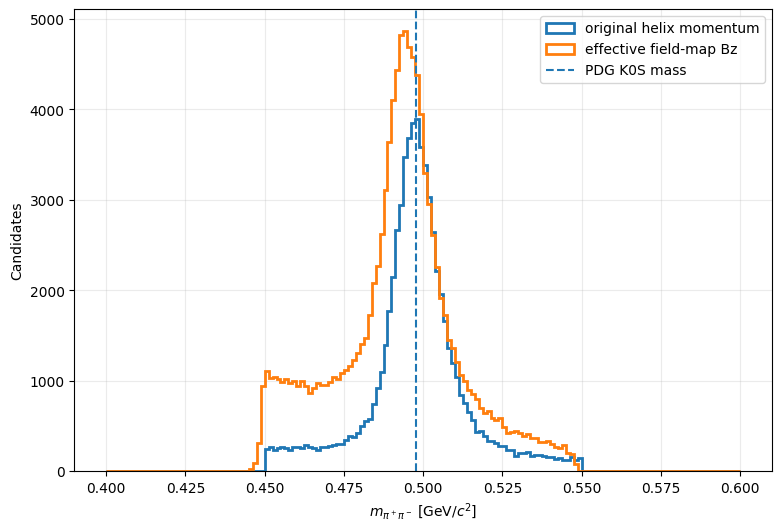

Magnetic-field map is ENABLED for all subsequent refits.
Candidates retained for training after field matching: 113769


In [6]:
# ============================================================
# Recalculate K0S mass using effective Bz
# ============================================================

def invariant_mass_numpy(
    px1,
    py1,
    pz1,
    px2,
    py2,
    pz2,
    mass1,
    mass2,
):
    momentum1_squared = (
        px1**2 + py1**2 + pz1**2
    )

    momentum2_squared = (
        px2**2 + py2**2 + pz2**2
    )

    energy1 = np.sqrt(
        momentum1_squared + mass1**2
    )

    energy2 = np.sqrt(
        momentum2_squared + mass2**2
    )

    total_px = px1 + px2
    total_py = py1 + py2
    total_pz = pz1 + pz2

    mass_squared = (
        (energy1 + energy2) ** 2
        - total_px**2
        - total_py**2
        - total_pz**2
    )

    return np.sqrt(
        np.maximum(mass_squared, 0.0)
    )


field_scale1 = (
    np.abs(
        candidates_field_test[
            "effective_bz1_tesla"
        ].to_numpy(float)
    )
    / nominal_magnetic_field_tesla
)

field_scale2 = (
    np.abs(
        candidates_field_test[
            "effective_bz2_tesla"
        ].to_numpy(float)
    )
    / nominal_magnetic_field_tesla
)

pt1_field = (
    candidates_field_test["pt1"].to_numpy(float)
    * field_scale1
)

pt2_field = (
    candidates_field_test["pt2"].to_numpy(float)
    * field_scale2
)

phi1 = candidates_field_test[
    "phi1"
].to_numpy(float)

phi2 = candidates_field_test[
    "phi2"
].to_numpy(float)

eta1 = candidates_field_test[
    "eta1"
].to_numpy(float)

eta2 = candidates_field_test[
    "eta2"
].to_numpy(float)

px1_field = pt1_field * np.cos(phi1)
py1_field = pt1_field * np.sin(phi1)
pz1_field = pt1_field * np.sinh(eta1)

px2_field = pt2_field * np.cos(phi2)
py2_field = pt2_field * np.sin(phi2)
pz2_field = pt2_field * np.sinh(eta2)

mass_original = candidates_field_test[
    "selected_mass"
].to_numpy(float)

mass_field_scaled = invariant_mass_numpy(
    px1_field,
    py1_field,
    pz1_field,
    px2_field,
    py2_field,
    pz2_field,
    pion_mass,
    pion_mass,
)

print(
    "Original mass mean [GeV]:",
    float(np.mean(mass_original)),
)

print(
    "Field-scaled mass mean [GeV]:",
    float(np.mean(mass_field_scaled)),
)

print(
    "Mean mass change [MeV]:",
    1000.0 * float(
        np.mean(
            mass_field_scaled - mass_original
        )
    ),
)

print(
    "Original mass RMS [MeV]:",
    1000.0 * float(np.std(mass_original)),
)

print(
    "Field-scaled mass RMS [MeV]:",
    1000.0 * float(np.std(mass_field_scaled)),
)

plt.figure(figsize=(9, 6))

plt.hist(
    mass_original,
    bins=160,
    range=(0.40, 0.60),
    histtype="step",
    linewidth=2,
    label="original helix momentum",
)

plt.hist(
    mass_field_scaled,
    bins=160,
    range=(0.40, 0.60),
    histtype="step",
    linewidth=2,
    label="effective field-map Bz",
)

plt.axvline(
    pdg_kshort_mass,
    linestyle="--",
    label="PDG K0S mass",
)

plt.xlabel(r"$m_{\pi^+\pi^-}$ [GeV/$c^2$]")
plt.ylabel("Candidates")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Store the tested field-scaled mass for later before/after QA.
candidates_field_test["field_scaled_mass"] = (
    mass_field_scaled.astype(np.float32)
)

# From this point onward, every training/validation candidate carries
# effective_bz{1,2}_tesla and field_scale{1,2}. This is the main table
# consumed by build_channel_arrays().
if use_magnetic_field_map_in_training:
    candidates = candidates_field_test.copy()

    print(
        "Magnetic-field map is ENABLED for all subsequent refits."
    )
    print(
        "Candidates retained for training after field matching:",
        len(candidates),
    )
else:
    candidates = candidates.copy()
    candidates["effective_bz1_tesla"] = nominal_magnetic_field_tesla
    candidates["effective_bz2_tesla"] = nominal_magnetic_field_tesla
    candidates["field_scale1"] = 1.0
    candidates["field_scale2"] = 1.0
    candidates["field_scaled_mass"] = candidates["selected_mass"]


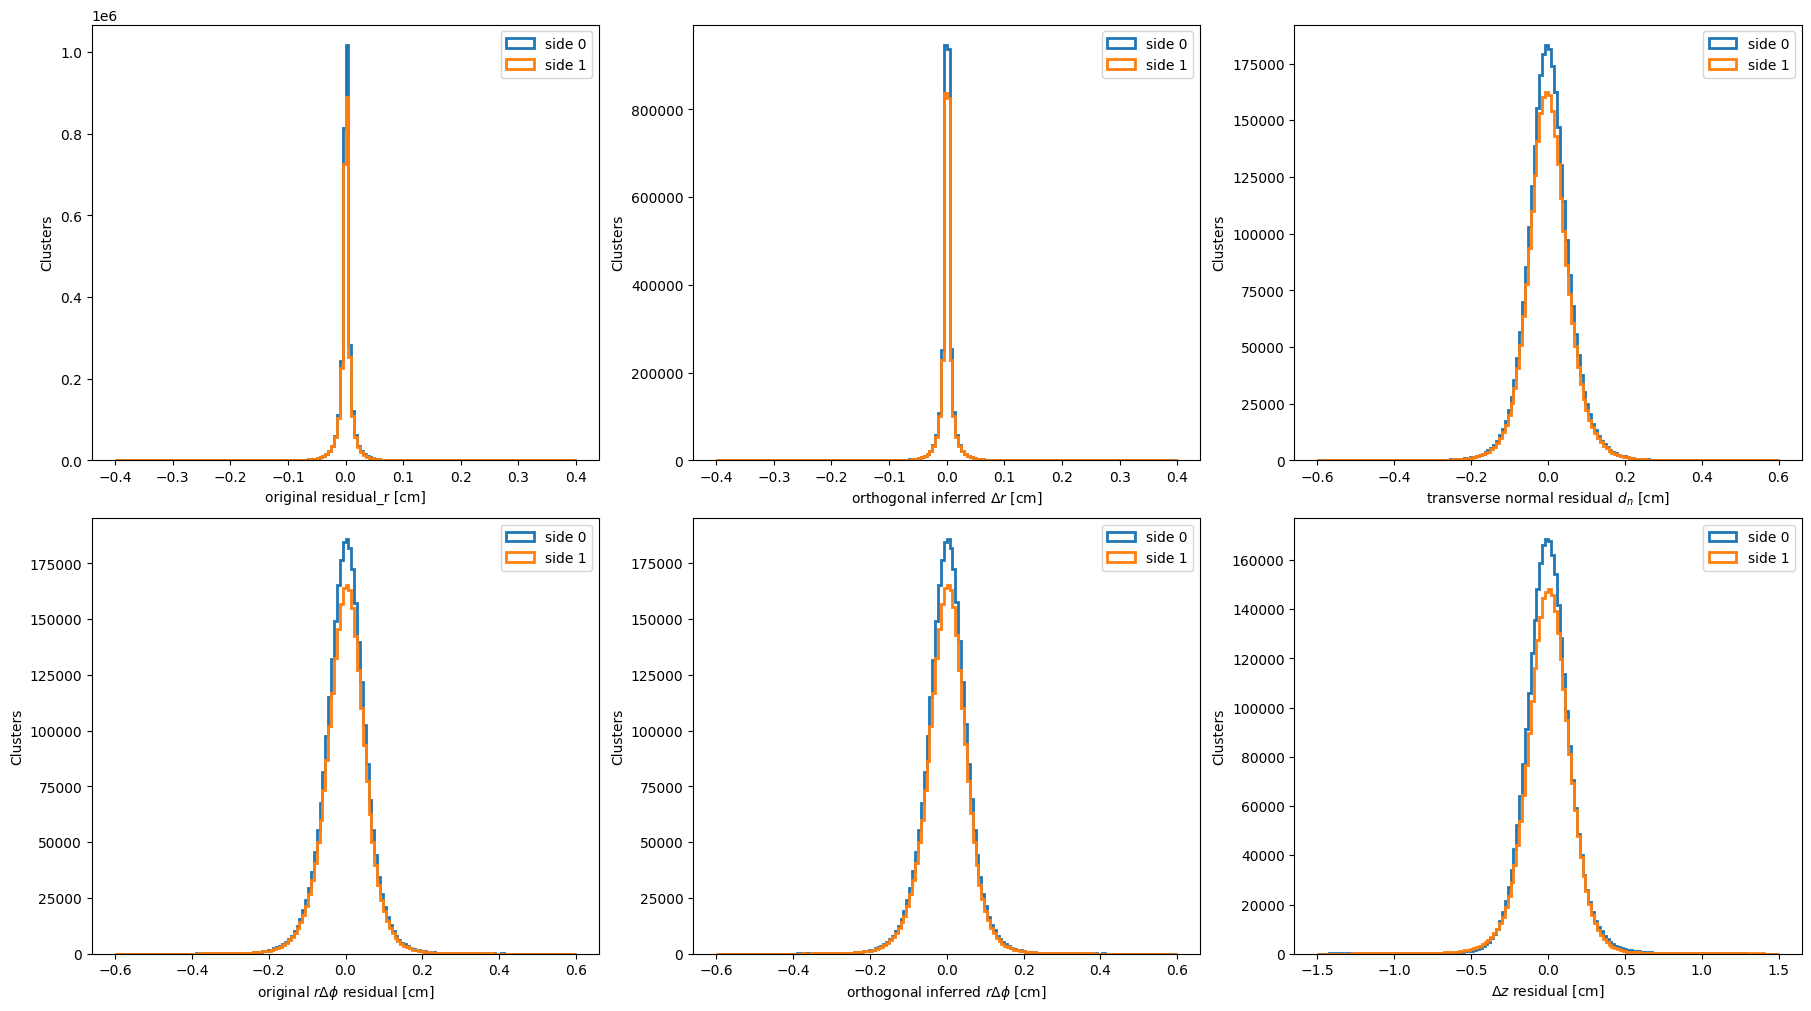

      residual_r  residual_r_orthogonal  residual_rphi  \
side                                                     
0       0.019930               0.016422       0.083142   
1       0.018433               0.016165       0.084311   

      residual_rphi_orthogonal  residual_normal_xy  residual_z  
side                                                            
0                     0.083375            0.084977    0.187091  
1                     0.084444            0.085978    0.189745  


In [7]:
# ============================================================
# Residual QA before training
# ============================================================

kshort_cluster_qa = clusters.loc[
    (clusters['channel'] == 0)
    & clusters['physical_side_z_valid'].astype(bool)
].copy()

figure, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

qa_definitions = [
    ('residual_r', r'original residual_r [cm]', (-0.40, 0.40)),
    ('residual_r_orthogonal', r'orthogonal inferred $\Delta r$ [cm]', (-0.40, 0.40)),
    ('residual_normal_xy', r'transverse normal residual $d_n$ [cm]', (-0.60, 0.60)),
    ('residual_rphi', r'original $r\Delta\phi$ residual [cm]', (-0.60, 0.60)),
    ('residual_rphi_orthogonal', r'orthogonal inferred $r\Delta\phi$ [cm]', (-0.60, 0.60)),
    ('residual_z', r'$\Delta z$ residual [cm]', (-1.50, 1.50)),
]

for axis, (column, label, value_range) in zip(axes.flat, qa_definitions):
    for side in [0, 1]:
        values = kshort_cluster_qa.loc[
            kshort_cluster_qa['side'] == side,
            column,
        ].to_numpy(float)
        values = values[np.isfinite(values)]
        axis.hist(
            values,
            bins=160,
            range=value_range,
            histtype='step',
            linewidth=2,
            label=f'side {side}',
        )
    axis.set_xlabel(label)
    axis.set_ylabel('Clusters')
    axis.legend()

plt.show()

# Directly demonstrate why the original residual_r is not used.
print(
    kshort_cluster_qa.groupby('side')[[
        'residual_r',
        'residual_r_orthogonal',
        'residual_rphi',
        'residual_rphi_orthogonal',
        'residual_normal_xy',
        'residual_z',
    ]].std()
)


## Build padded candidate tensors and cache them once

Residual pretraining later flattens the valid clusters into large batches. Hybrid mass fine-tuning uses the padded candidate representation so both daughter tracks can be corrected and refitted together.


In [8]:
# ============================================================
# Candidate-to-cluster tensor construction
# ============================================================

def clean_track_clusters(frame):
    frame = frame.copy()

    finite = (
        np.isfinite(frame['cluster_r'])
        & np.isfinite(frame['cluster_phi'])
        & np.isfinite(frame['cluster_z'])
        & np.isfinite(frame['residual_normal_xy'])
        & np.isfinite(frame['normal_projection_r'])
        & np.isfinite(frame['normal_projection_rphi'])
        & np.isfinite(frame['sigma_normal'])
        & np.isfinite(frame['residual_z'])
        & np.isfinite(frame['sigma_z_filled'])
    )

    frame = frame.loc[finite]
    frame = frame.loc[frame['physical_side_z_valid'].astype(bool)]
    frame = frame.loc[(frame['layer'] >= 7) & (frame['layer'] <= 54)]

    # Remove radial-module boundary layers before all downstream
    # cluster-count, module-coverage, radial-span, and fit operations.
    frame = frame.loc[
        ~frame['layer'].isin(excluded_layers)
    ]
    frame = frame.loc[
        (np.abs(frame['residual_normal_xy']) < maximum_abs_residual_normal_cm)
        & (np.abs(frame['residual_z']) < maximum_abs_residual_z_cm)
    ]

    if use_recommended_clusters_only:
        frame = frame.loc[
            frame['recommended_for_reference_fit'].astype(bool)
        ]

    if use_kalman_used_clusters_only:
        frame = frame.loc[
            frame['kalman_measurement_used'].astype(bool)
        ]

    sort_columns = ['layer']
    if 'kalman_measurement_chi2' in frame.columns:
        sort_columns.append('kalman_measurement_chi2')

    frame = frame.sort_values(sort_columns)
    frame = frame.drop_duplicates('layer', keep='first')

    radial_modules = set(
        frame.loc[
            frame['radial_module'] >= 0,
            'radial_module',
        ].astype(int)
    )

    if len(radial_modules) < minimum_tpc_modules_per_track:
        return frame.iloc[0:0]

    if len(frame):
        radial_span_cm = (
            float(frame['cluster_r'].max())
            - float(frame['cluster_r'].min())
        )
    else:
        radial_span_cm = 0.0

    if radial_span_cm < minimum_track_radial_span_cm:
        return frame.iloc[0:0]

    return frame.sort_values('layer').head(maximum_clusters)


def smooth_pair_weights(pt1, pt2):
    if not use_smooth_track_pt_reweighting:
        return np.ones(len(pt1), dtype=np.float32)

    all_pt = np.concatenate([pt1, pt2]).astype(float)
    safe = np.clip(all_pt, 0.20, 5.00)
    edges = np.linspace(np.log(0.20), np.log(5.00), 81)
    centers = 0.5 * (edges[:-1] + edges[1:])
    counts, _ = np.histogram(np.log(safe), bins=edges)

    offsets = np.arange(-8, 9, dtype=float)
    kernel = np.exp(-0.5 * (offsets / 2.0) ** 2)
    kernel /= kernel.sum()

    density = np.convolve(counts.astype(float), kernel, mode='same')
    positive = density[density > 0]
    reference = np.median(positive) if len(positive) else 1.0
    density = np.maximum(density, 0.05 * max(reference, 1.0))

    weights = (reference / density) ** track_pt_weight_power
    weights = np.clip(weights, 0.35, 3.0)

    def evaluate(values):
        return np.interp(
            np.log(np.clip(values, 0.20, 5.00)),
            centers,
            weights,
            left=weights[0],
            right=weights[-1],
        )

    pair = np.sqrt(evaluate(pt1) * evaluate(pt2))
    pair /= np.mean(pair)

    return np.clip(
        pair,
        minimum_pair_weight,
        maximum_pair_weight,
    ).astype(np.float32)


def build_channel_arrays(channel, side):
    candidate_frame = candidates.loc[
        (candidates['channel'] == channel)
        & candidates['same_side'].astype(bool)
        & (candidates['side1'] == side)
        & (candidates['side2'] == side)
    ].copy()

    if channel == 0:
        candidate_frame = candidate_frame.loc[
            candidate_frame['pass_cut03'].astype(bool)
            & candidate_frame['pass_pion_pid'].astype(bool)
            & candidate_frame['pass_signed_delta_phi'].astype(bool)
        ]

    channel_clusters = clusters.loc[
        (clusters['channel'] == channel)
        & (clusters['side'] == side)
    ]

    grouped = {
        key: value
        for key, value in channel_clusters.groupby(
            ['candidate_id', 'daughter'],
            sort=False,
        )
    }

    records = []

    for row in candidate_frame.itertuples(index=False):
        key1 = (row.candidate_id, 1)
        key2 = (row.candidate_id, 2)

        if key1 not in grouped or key2 not in grouped:
            continue

        first = clean_track_clusters(grouped[key1])
        second = clean_track_clusters(grouped[key2])

        if (
            len(first) < minimum_clusters_per_track
            or len(second) < minimum_clusters_per_track
        ):
            continue

        records.append((row, first, second))

    if not records:
        raise RuntimeError(
            f'No usable candidates for channel={channel}, side={side}'
        )

    number = len(records)
    shape = (number, maximum_clusters)

    output = {
        key: np.zeros(shape, dtype=np.float32)
        for key in [
            'r1', 'phi1_cluster', 'z1_cluster',
            'res_normal1', 'normal_projection_r1', 'normal_projection_rphi1',
            'sigma_normal1', 'res_z1', 'sigma_z1', 'mask1',
            'r2', 'phi2_cluster', 'z2_cluster',
            'res_normal2', 'normal_projection_r2', 'normal_projection_rphi2',
            'sigma_normal2', 'res_z2', 'sigma_z2', 'mask2',
        ]
    }

    scalar_names = [
        'candidate_id', 'event_parity', 'selected_mass', 'pair_pt',
        'pca_x', 'pca_y', 'pca_z',
        'charge1', 'charge2', 'pt1', 'pt2', 'phi1', 'phi2', 'eta1', 'eta2',
        'px1', 'py1', 'pz1', 'px2', 'py2', 'pz2',
        'effective_bz1_tesla', 'effective_bz2_tesla',
        'field_scale1', 'field_scale2', 'field_scaled_mass',
    ]

    for name in scalar_names:
        output[name] = np.zeros(number, dtype=np.float32)

    def fill_track(index, frame, suffix):
        count = len(frame)

        output[f'r{suffix}'][index, :count] = frame[
            'cluster_r'
        ].to_numpy(np.float32)

        output[f'phi{suffix}_cluster'][index, :count] = frame[
            'cluster_phi'
        ].to_numpy(np.float32)

        output[f'z{suffix}_cluster'][index, :count] = frame[
            'cluster_z'
        ].to_numpy(np.float32)

        output[f'res_normal{suffix}'][index, :count] = frame[
            'residual_normal_xy'
        ].to_numpy(np.float32)

        output[f'normal_projection_r{suffix}'][index, :count] = frame[
            'normal_projection_r'
        ].to_numpy(np.float32)

        output[f'normal_projection_rphi{suffix}'][index, :count] = frame[
            'normal_projection_rphi'
        ].to_numpy(np.float32)

        output[f'sigma_normal{suffix}'][index, :count] = frame[
            'sigma_normal'
        ].to_numpy(np.float32)

        output[f'res_z{suffix}'][index, :count] = frame[
            'residual_z'
        ].to_numpy(np.float32)

        output[f'sigma_z{suffix}'][index, :count] = frame[
            'sigma_z_filled'
        ].to_numpy(np.float32)

        output[f'mask{suffix}'][index, :count] = 1.0

    for index, (row, first, second) in enumerate(records):
        for name in scalar_names:
            output[name][index] = getattr(row, name)

        fill_track(index, first, '1')
        fill_track(index, second, '2')

    output['pair_weight'] = smooth_pair_weights(
        output['pt1'],
        output['pt2'],
    )

    output['channel'] = np.full(number, channel, dtype=np.int64)
    output['side'] = np.full(number, side, dtype=np.int64)

    print(
        f'channel={channel}, side={side}: '
        f'{number} usable candidates'
    )

    print(
        f'channel={channel}, side={side}: '
        f'mean effective Bz daughter 1/2 = '
        f'{float(np.mean(output["effective_bz1_tesla"])):.6f} / '
        f'{float(np.mean(output["effective_bz2_tesla"])):.6f} T'
    )

    return output


kshort_arrays = {
    side: build_channel_arrays(0, side)
    for side in [0, 1]
}

validation_arrays = {}

for channel in [1, 2]:
    for side in [0, 1]:
        try:
            validation_arrays[(channel, side)] = build_channel_arrays(
                channel,
                side,
            )
        except RuntimeError as error:
            print(error)


channel=0, side=0: 35426 usable candidates
channel=0, side=0: mean effective Bz daughter 1/2 = 1.386139 / 1.387018 T
channel=0, side=1: 31524 usable candidates
channel=0, side=1: mean effective Bz daughter 1/2 = 1.387862 / 1.388635 T
channel=1, side=0: 12081 usable candidates
channel=1, side=0: mean effective Bz daughter 1/2 = 1.386806 / 1.386208 T
channel=1, side=1: 9821 usable candidates
channel=1, side=1: mean effective Bz daughter 1/2 = 1.388346 / 1.388305 T
channel=2, side=0: 11202 usable candidates
channel=2, side=0: mean effective Bz daughter 1/2 = 1.386249 / 1.386466 T
channel=2, side=1: 9588 usable candidates
channel=2, side=1: mean effective Bz daughter 1/2 = 1.388051 / 1.388001 T


In [9]:
# ============================================================
# Cache side arrays for parallel workers
# ============================================================

kshort_npz_files = {}
validation_npz_files = {}

for side, arrays in kshort_arrays.items():
    output_file = cache_dir / f'kshort_side{side}.npz'
    np.savez_compressed(output_file, **arrays)
    kshort_npz_files[side] = output_file
    print('Wrote:', output_file)

for (channel, side), arrays in validation_arrays.items():
    output_file = cache_dir / f'channel{channel}_side{side}.npz'
    np.savez_compressed(output_file, **arrays)
    validation_npz_files[(channel, side)] = output_file
    print('Wrote:', output_file)


def load_npz_dictionary(path):
    with np.load(path, allow_pickle=False) as input_file:
        return {
            key: input_file[key]
            for key in input_file.files
        }


Wrote: output/v0_spatial_residual_dnn_new_v3_conservative/tensor_cache/kshort_side0.npz
Wrote: output/v0_spatial_residual_dnn_new_v3_conservative/tensor_cache/kshort_side1.npz
Wrote: output/v0_spatial_residual_dnn_new_v3_conservative/tensor_cache/channel1_side0.npz
Wrote: output/v0_spatial_residual_dnn_new_v3_conservative/tensor_cache/channel1_side1.npz
Wrote: output/v0_spatial_residual_dnn_new_v3_conservative/tensor_cache/channel2_side0.npz
Wrote: output/v0_spatial_residual_dnn_new_v3_conservative/tensor_cache/channel2_side1.npz


In [10]:
# ============================================================
# PyTorch datasets
# ============================================================

class CandidateDataset(Dataset):
    def __init__(self, arrays, indices):
        self.data = {}
        number_of_candidates = len(arrays['candidate_id'])

        for key, values in arrays.items():
            if (
                isinstance(values, np.ndarray)
                and len(values) == number_of_candidates
            ):
                self.data[key] = torch.from_numpy(values[indices])

    def __len__(self):
        return len(self.data['candidate_id'])

    def __getitem__(self, index):
        return {
            key: value[index]
            for key, value in self.data.items()
        }


class ResidualDataset(Dataset):
    def __init__(self, arrays):
        self.data = {
            key: torch.from_numpy(value)
            for key, value in arrays.items()
        }

    def __len__(self):
        return len(self.data['r'])

    def __getitem__(self, index):
        return {
            key: value[index]
            for key, value in self.data.items()
        }


def flatten_training_clusters(arrays, candidate_indices):
    output_lists = {
        key: []
        for key in [
            'r', 'phi', 'z',
            'res_normal',
            'normal_projection_r',
            'normal_projection_rphi',
            'sigma_normal',
            'res_z', 'sigma_z',
        ]
    }

    for suffix in ['1', '2']:
        mask = arrays[f'mask{suffix}'][candidate_indices] > 0.5

        source_names = {
            'r': f'r{suffix}',
            'phi': f'phi{suffix}_cluster',
            'z': f'z{suffix}_cluster',
            'res_normal': f'res_normal{suffix}',
            'normal_projection_r': f'normal_projection_r{suffix}',
            'normal_projection_rphi': f'normal_projection_rphi{suffix}',
            'sigma_normal': f'sigma_normal{suffix}',
            'res_z': f'res_z{suffix}',
            'sigma_z': f'sigma_z{suffix}',
        }

        for output_name, source_name in source_names.items():
            output_lists[output_name].append(
                arrays[source_name][candidate_indices][mask].astype(np.float32)
            )

    output = {
        key: np.concatenate(value).astype(np.float32)
        for key, value in output_lists.items()
    }

    return output


## Smooth drift field plus explicit pad-plane geometry

Each side has an independent model.

The transverse field contains three pieces:

1. a smooth drift-dependent DNN field;
2. a side-level pad-plane alignment field with independent \(\Delta r\), \(r\Delta\phi\), and four tilt-like transverse gradient coefficients;
3. one small transverse offset for each of the 36 modules on that side.

The side and module terms are multiplied by the pad-plane fraction

\[
p = 1-u = 
rac{|z|}{z_{
m pad}},
\]

so they are fully expressed at the pad plane and vanish at the central membrane. The DNN distortion is multiplied by \(u\), as before.

The side-level alignment parameters are bounded by the selected geometry profile. Local module corrections are independently bounded by `maximum_module_offset_cm`. The two sides start from the same 300 μm transverse offset but are optimized independently.

The optional longitudinal correction retains the original hard boundary and is exactly zero at the pad plane.


In [11]:
# ============================================================
# Spatial network and differentiable refit helpers
# ============================================================

class SpatialResidualNetwork(nn.Module):
    number_of_sectors = 12
    number_of_radial_modules = 3
    number_of_local_modules = (
        number_of_sectors * number_of_radial_modules
    )

    def __init__(self, side):
        super().__init__()

        if side not in (0, 1):
            raise ValueError('side must be 0 or 1')

        self.side = int(side)

        radial_centers = torch.linspace(
            radial_basis_minimum_cm,
            radial_basis_maximum_cm,
            number_of_radial_basis_functions,
        )

        radial_spacing = (
            radial_basis_maximum_cm
            - radial_basis_minimum_cm
        ) / max(number_of_radial_basis_functions - 1, 1)

        self.register_buffer('radial_centers', radial_centers)
        self.radial_width = radial_basis_width_scale * radial_spacing

        input_width = (
            number_of_radial_basis_functions
            + 2 * number_of_phi_harmonics
            + 2
        )

        layers = []
        width = input_width

        for _ in range(hidden_layers):
            layers.extend([
                nn.Linear(width, hidden_width),
                nn.SiLU(),
                nn.Dropout(dropout_probability),
            ])
            width = hidden_width

        self.trunk = nn.Sequential(*layers)
        self.output = nn.Linear(
            width,
            3 if include_z_correction else 2,
        )

        # The smooth drift-dependent DNN starts from zero.
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

        # ----------------------------------------------------
        # Side-level pad-plane alignment
        # ----------------------------------------------------
        #
        # The first two parameters represent constant Delta r
        # and rDeltaPhi offsets at the pad plane.
        #
        # The four tilt parameters describe linear variation in
        # the normalized transverse coordinates:
        #
        # Delta r tilt       = a_x * x_norm + a_y * y_norm
        # rDeltaPhi tilt     = b_x * x_norm + b_y * y_norm
        #
        # tanh keeps every contribution inside its configured
        # physical bound.

        initial_delta_r = float(initial_side_delta_r_cm[self.side])
        initial_rdelta_phi = float(
            initial_side_rdelta_phi_cm[self.side]
        )

        self.side_offset_raw = nn.Parameter(torch.tensor([
            self.inverse_bounded_tanh(
                initial_delta_r,
                maximum_side_offset_cm,
            ),
            self.inverse_bounded_tanh(
                initial_rdelta_phi,
                maximum_side_offset_cm,
            ),
        ], dtype=torch.float32))

        initial_tilt = initial_side_tilt_coefficients[self.side]
        if len(initial_tilt) != 4:
            raise ValueError(
                'Each side requires four initial tilt coefficients'
            )

        self.side_tilt_raw = nn.Parameter(torch.tensor([
            self.inverse_bounded_tanh(
                float(value),
                maximum_side_tilt_displacement_cm,
            )
            for value in initial_tilt
        ], dtype=torch.float32))

        # One Delta r and one rDeltaPhi displacement for each
        # of the 36 modules on this side. They begin at zero.
        self.module_offset_raw = nn.Parameter(torch.zeros(
            self.number_of_local_modules,
            2,
            dtype=torch.float32,
        ))

    @staticmethod
    def inverse_bounded_tanh(value, maximum):
        if maximum <= 0:
            return 0.0

        ratio = max(
            min(float(value) / float(maximum), 0.999999),
            -0.999999,
        )

        return math.atanh(ratio)

    def physical_domain_and_drift_fraction(self, z):
        if self.side == 0:
            physical = (
                (z <= central_membrane_tolerance_cm)
                & (z >= -z_pad_cm - pad_plane_tolerance_cm)
            )
        else:
            physical = (
                (z >= -central_membrane_tolerance_cm)
                & (z <= z_pad_cm + pad_plane_tolerance_cm)
            )

        drift_fraction = torch.clamp(
            1.0 - torch.abs(z) / z_pad_cm,
            min=0.0,
            max=1.0,
        )

        pad_plane_fraction = 1.0 - drift_fraction

        return (
            physical.to(z.dtype),
            drift_fraction,
            pad_plane_fraction,
        )

    def features(self, r, phi, z):
        radial = torch.exp(
            -0.5
            * (
                (
                    r[..., None]
                    - self.radial_centers
                )
                / self.radial_width
            ) ** 2
        )

        phi_features = []

        for harmonic in range(1, number_of_phi_harmonics + 1):
            phi_features.extend([
                torch.sin(harmonic * phi)[..., None],
                torch.cos(harmonic * phi)[..., None],
            ])

        _, drift_fraction, _ = (
            self.physical_domain_and_drift_fraction(z)
        )

        return torch.cat([
            radial,
            *phi_features,
            drift_fraction[..., None],
            (drift_fraction ** 2)[..., None],
        ], dim=-1)

    def local_module_index(self, r, phi):
        # Radial module from the known TPC boundaries.
        radial_module = torch.zeros_like(r, dtype=torch.long)
        radial_module = torch.where(
            r >= 41.153,
            torch.ones_like(radial_module),
            radial_module,
        )
        radial_module = torch.where(
            r >= 58.367,
            torch.full_like(radial_module, 2),
            radial_module,
        )
        radial_module = torch.clamp(radial_module, 0, 2)

        wrapped_phi = torch.remainder(
            phi + math.pi,
            2.0 * math.pi,
        )

        sector = torch.floor(
            wrapped_phi / (2.0 * math.pi / 12.0)
        ).to(torch.long)
        sector = torch.clamp(sector, 0, 11)

        return 12 * radial_module + sector

    def side_alignment_field(self, r, phi):
        side_offset = (
            maximum_side_offset_cm
            * torch.tanh(self.side_offset_raw)
        )

        tilt = (
            maximum_side_tilt_displacement_cm
            * torch.tanh(self.side_tilt_raw)
        )

        # Normalize x and y by the outer TPC radius. This makes
        # each tilt coefficient approximately the displacement
        # scale reached near the outer edge.
        x_normalized = (
            r * torch.cos(phi)
            / radial_basis_maximum_cm
        )
        y_normalized = (
            r * torch.sin(phi)
            / radial_basis_maximum_cm
        )

        delta_r = (
            side_offset[0]
            + tilt[0] * x_normalized
            + tilt[1] * y_normalized
        )

        r_delta_phi = (
            side_offset[1]
            + tilt[2] * x_normalized
            + tilt[3] * y_normalized
        )

        return delta_r, r_delta_phi

    def module_alignment_field(self, r, phi):
        module_index = self.local_module_index(r, phi)

        bounded_module_offsets = (
            maximum_module_offset_cm
            * torch.tanh(self.module_offset_raw)
        )

        selected = bounded_module_offsets[module_index]

        return selected[..., 0], selected[..., 1]

    def alignment_parameters(self):
        return {
            'side_offset': (
                maximum_side_offset_cm
                * torch.tanh(self.side_offset_raw)
            ),
            'side_tilt': (
                maximum_side_tilt_displacement_cm
                * torch.tanh(self.side_tilt_raw)
            ),
            'module_offset': (
                maximum_module_offset_cm
                * torch.tanh(self.module_offset_raw)
            ),
        }

    def forward(self, r, phi, z):
        (
            physical,
            drift_fraction,
            pad_plane_fraction,
        ) = self.physical_domain_and_drift_fraction(z)

        feature_tensor = self.features(r, phi, z)
        original_shape = r.shape

        raw = self.output(
            self.trunk(
                feature_tensor.reshape(
                    -1,
                    feature_tensor.shape[-1],
                )
            )
        ).reshape(*original_shape, -1)

        drift_delta_r = (
            drift_fraction
            * maximum_delta_r_cm
            * torch.tanh(raw[..., 0])
        )

        drift_r_delta_phi = (
            drift_fraction
            * maximum_r_delta_phi_cm
            * torch.tanh(raw[..., 1])
        )

        side_delta_r, side_r_delta_phi = (
            self.side_alignment_field(r, phi)
        )

        module_delta_r, module_r_delta_phi = (
            self.module_alignment_field(r, phi)
        )

        pad_delta_r = pad_plane_fraction * (
            side_delta_r + module_delta_r
        )

        pad_r_delta_phi = pad_plane_fraction * (
            side_r_delta_phi + module_r_delta_phi
        )

        delta_r = physical * (
            drift_delta_r + pad_delta_r
        )

        r_delta_phi = physical * (
            drift_r_delta_phi + pad_r_delta_phi
        )

        if include_z_correction:
            delta_z = (
                physical
                * drift_fraction
                * maximum_delta_z_cm
                * torch.tanh(raw[..., 2])
            )
        else:
            delta_z = torch.zeros_like(delta_r)

        return delta_r, r_delta_phi, delta_z

def wrap_phi_torch(value):
    return torch.atan2(
        torch.sin(value),
        torch.cos(value),
    )


def masked_circle_fit(x, y, mask):
    ones = torch.ones_like(x)
    design = torch.stack([x, y, ones], dim=2)
    target = -(x * x + y * y)[:, :, None]
    weight = mask[:, :, None]

    weighted_design = design * weight
    normal = design.transpose(1, 2) @ weighted_design
    rhs = design.transpose(1, 2) @ (target * weight)

    identity = torch.eye(
        3,
        dtype=x.dtype,
        device=x.device,
    )[None]

    parameters = torch.linalg.solve(
        normal + 1.0e-7 * identity,
        rhs,
    )[:, :, 0]

    coefficient_a = parameters[:, 0]
    coefficient_b = parameters[:, 1]
    coefficient_c = parameters[:, 2]

    center_x = -0.5 * coefficient_a
    center_y = -0.5 * coefficient_b

    radius = torch.sqrt(
        torch.clamp(
            0.25 * (
                coefficient_a ** 2
                + coefficient_b ** 2
            ) - coefficient_c,
            min=1.0e-8,
        )
    )

    return center_x, center_y, radius


def tangent_phi_at_vertex(
    center_x,
    center_y,
    radius,
    charge,
    vertex_x,
    vertex_y,
):
    dx = vertex_x - center_x
    dy = vertex_y - center_y

    distance = torch.sqrt(
        torch.clamp(
            dx * dx + dy * dy,
            min=1.0e-12,
        )
    )

    point_x = center_x + radius * dx / distance
    point_y = center_y + radius * dy / distance

    omega = -charge / radius
    sin_phi = omega * (point_x - center_x)
    cos_phi = -omega * (point_y - center_y)

    return torch.atan2(sin_phi, cos_phi)


def longitudinal_slope(x, y, z, mask, center_x, center_y, radius):
    theta = torch.atan2(
        y - center_y[:, None],
        x - center_x[:, None],
    )

    delta = wrap_phi_torch(
        theta[:, 1:] - theta[:, :-1]
    )

    pair_mask = mask[:, 1:] * mask[:, :-1]
    ds = radius[:, None] * torch.abs(delta) * pair_mask

    path_length = torch.cat([
        torch.zeros_like(ds[:, :1]),
        torch.cumsum(ds, dim=1),
    ], dim=1)

    weight_sum = torch.clamp(mask.sum(dim=1), min=1.0)
    mean_s = (path_length * mask).sum(dim=1) / weight_sum
    mean_z = (z * mask).sum(dim=1) / weight_sum

    covariance = (
        (path_length - mean_s[:, None])
        * (z - mean_z[:, None])
        * mask
    ).sum(dim=1)

    variance = (
        (path_length - mean_s[:, None]) ** 2
        * mask
    ).sum(dim=1)

    return covariance / torch.clamp(variance, min=1.0e-8)


def refit_track(
    model,
    r,
    phi,
    z,
    mask,
    charge,
    original_pt,
    original_phi,
    original_eta,
    effective_bz_tesla,
    vertex_x,
    vertex_y,
):
    raw_x = r * torch.cos(phi)
    raw_y = r * torch.sin(phi)

    raw_center_x, raw_center_y, raw_radius = masked_circle_fit(
        raw_x,
        raw_y,
        mask,
    )

    raw_fit_phi = tangent_phi_at_vertex(
        raw_center_x,
        raw_center_y,
        raw_radius,
        charge,
        vertex_x,
        vertex_y,
    )

    raw_slope = longitudinal_slope(
        raw_x,
        raw_y,
        z,
        mask,
        raw_center_x,
        raw_center_y,
        raw_radius,
    )

    delta_r, r_delta_phi, delta_z = model(r, phi, z)

    corrected_r = r - delta_r * mask
    corrected_phi = (
        phi
        - (
            r_delta_phi
            / torch.clamp(r, min=1.0e-6)
        ) * mask
    )
    corrected_z = z - delta_z * mask

    corrected_x = corrected_r * torch.cos(corrected_phi)
    corrected_y = corrected_r * torch.sin(corrected_phi)

    center_x, center_y, radius = masked_circle_fit(
        corrected_x,
        corrected_y,
        mask,
    )

    fitted_phi = tangent_phi_at_vertex(
        center_x,
        center_y,
        radius,
        charge,
        vertex_x,
        vertex_y,
    )

    fitted_slope = longitudinal_slope(
        corrected_x,
        corrected_y,
        corrected_z,
        mask,
        center_x,
        center_y,
        radius,
    )

    # Effective-field momentum scaling:
    #
    #   pT(corrected) = pT(original)
    #                   * |<Bz>track| / Bnominal
    #                   * Rcorrected / Rraw
    #
    # <Bz>track is precomputed from the tested 3-D field map using all
    # accepted original clusters of this daughter. It is supplied as a
    # cached scalar, so this operation remains differentiable with respect
    # to the DNN-induced radius change.
    field_scale = torch.where(
        torch.isfinite(effective_bz_tesla),
        torch.abs(effective_bz_tesla)
        / nominal_magnetic_field_tesla,
        torch.ones_like(effective_bz_tesla),
    )

    field_scale = torch.clamp(
        field_scale,
        min=0.5,
        max=1.5,
    )

    corrected_pt = (
        original_pt
        * field_scale
        * radius
        / torch.clamp(raw_radius, min=1.0e-6)
    )

    corrected_momentum_phi = (
        original_phi
        + wrap_phi_torch(
            fitted_phi - raw_fit_phi
        )
    )

    corrected_sinh_eta = (
        torch.sinh(original_eta)
        + (fitted_slope - raw_slope)
    )

    px = corrected_pt * torch.cos(corrected_momentum_phi)
    py = corrected_pt * torch.sin(corrected_momentum_phi)
    pz = corrected_pt * corrected_sinh_eta

    momentum = torch.stack([px, py, pz], dim=1)

    return {
        'momentum': momentum,
        'pt': corrected_pt,
        'phi': corrected_momentum_phi,
        'delta_r': delta_r,
        'r_delta_phi': r_delta_phi,
        'delta_z': delta_z,
        'effective_bz_tesla': effective_bz_tesla,
        'field_scale': field_scale,
        'raw_radius': raw_radius,
        'corrected_radius': radius,
    }


def invariant_mass(momentum1, momentum2, mass1, mass2):
    energy1 = torch.sqrt(
        torch.sum(momentum1 ** 2, dim=1)
        + mass1 ** 2
    )

    energy2 = torch.sqrt(
        torch.sum(momentum2 ** 2, dim=1)
        + mass2 ** 2
    )

    total = momentum1 + momentum2

    mass_squared = (
        (energy1 + energy2) ** 2
        - torch.sum(total ** 2, dim=1)
    )

    return torch.sqrt(
        torch.clamp(mass_squared, min=0.0)
    )


In [12]:
# ============================================================
# Mass prefit and likelihood
# ============================================================

SQRT_TWO = math.sqrt(2.0)


def cdf_scalar(value):
    return 0.5 * (
        1.0
        + math.erf(float(value) / SQRT_TWO)
    )


def mass_pdf_numpy(
    mass,
    fraction,
    mean,
    sigma,
    slope,
    minimum,
    maximum,
):
    mass = np.asarray(mass, dtype=float)

    lower = cdf_scalar((minimum - mean) / sigma)
    upper = cdf_scalar((maximum - mean) / sigma)

    normalization = (
        sigma
        * math.sqrt(2.0 * math.pi)
        * max(upper - lower, 1.0e-12)
    )

    signal = np.exp(
        -0.5 * ((mass - mean) / sigma) ** 2
    ) / normalization

    normalized_mass = (
        2.0 * mass - maximum - minimum
    ) / (maximum - minimum)

    background = np.clip(
        (1.0 + slope * normalized_mass)
        / (maximum - minimum),
        1.0e-12,
        None,
    )

    return (
        fraction * signal
        + (1.0 - fraction) * background
    )


def fit_mass_model(values, minimum=min_k0s_mass, maximum=max_k0s_mass):
    values = np.asarray(values, dtype=float)
    values = values[
        (values >= minimum)
        & (values <= maximum)
    ]

    def objective(parameters):
        fraction, mean, sigma, slope = parameters
        probability = mass_pdf_numpy(
            values,
            fraction,
            mean,
            sigma,
            slope,
            minimum,
            maximum,
        )

        return -np.sum(
            np.log(
                np.clip(probability, 1.0e-15, None)
            )
        )

    result = minimize(
        objective,
        [0.55, 0.495, 0.009, 0.0],
        method='L-BFGS-B',
        bounds=[
            (0.05, 0.95),
            (0.475, 0.515),
            (0.003, 0.025),
            (-0.9, 0.9),
        ],
    )

    return {
        'signal_fraction': float(result.x[0]),
        'raw_mean': float(result.x[1]),
        'signal_sigma': float(result.x[2]),
        'background_slope': float(result.x[3]),
        'mass_minimum': minimum,
        'mass_maximum': maximum,
    }


mass_models = {}

for side in [0, 1]:
    arrays = kshort_arrays[side]
    training_mask = (
        arrays['event_parity'].astype(int)
        == training_parity
    )

    mass_models[side] = fit_mass_model(
        arrays['selected_mass'][training_mask]
    )

    print('side', side, mass_models[side])


def mass_nll_per_candidate(mass, model):
    fraction = model['signal_fraction']
    sigma = model['signal_sigma']
    slope = model['background_slope']
    minimum = model['mass_minimum']
    maximum = model['mass_maximum']

    lower = cdf_scalar(
        (minimum - pdg_kshort_mass) / sigma
    )
    upper = cdf_scalar(
        (maximum - pdg_kshort_mass) / sigma
    )

    normalization = (
        sigma
        * math.sqrt(2.0 * math.pi)
        * max(upper - lower, 1.0e-12)
    )

    signal = torch.exp(
        -0.5
        * ((mass - pdg_kshort_mass) / sigma) ** 2
    ) / normalization

    normalized_mass = (
        2.0 * mass - maximum - minimum
    ) / (maximum - minimum)

    background = torch.clamp(
        (1.0 + slope * normalized_mass)
        / (maximum - minimum),
        min=1.0e-12,
    )

    probability = (
        fraction * signal
        + (1.0 - fraction) * background
    )

    return -torch.log(
        torch.clamp(probability, min=1.0e-12)
    )


side 0 {'signal_fraction': 0.860145315484762, 'raw_mean': 0.4984184903846917, 'signal_sigma': 0.009737583147999522, 'background_slope': -0.6963125314352443, 'mass_minimum': 0.4, 'mass_maximum': 0.6}
side 1 {'signal_fraction': 0.8601689547885915, 'raw_mean': 0.49803221471705816, 'signal_sigma': 0.00969453256051926, 'background_slope': -0.5206485099956429, 'mass_minimum': 0.4, 'mass_maximum': 0.6}


In [13]:
# ============================================================
# Batch correction and losses
# ============================================================

def correct_batch(model, batch, channel=0):
    first = refit_track(
        model,
        batch['r1'],
        batch['phi1_cluster'],
        batch['z1_cluster'],
        batch['mask1'],
        batch['charge1'],
        batch['pt1'],
        batch['phi1'],
        batch['eta1'],
        batch['effective_bz1_tesla'],
        batch['pca_x'],
        batch['pca_y'],
    )

    second = refit_track(
        model,
        batch['r2'],
        batch['phi2_cluster'],
        batch['z2_cluster'],
        batch['mask2'],
        batch['charge2'],
        batch['pt2'],
        batch['phi2'],
        batch['eta2'],
        batch['effective_bz2_tesla'],
        batch['pca_x'],
        batch['pca_y'],
    )

    if channel == 0:
        mass1 = mass2 = pion_mass
    elif channel == 1:
        mass1 = torch.where(
            batch['charge1'] > 0,
            torch.full_like(batch['charge1'], proton_mass),
            torch.full_like(batch['charge1'], pion_mass),
        )
        mass2 = torch.where(
            batch['charge2'] > 0,
            torch.full_like(batch['charge2'], proton_mass),
            torch.full_like(batch['charge2'], pion_mass),
        )
    else:
        mass1 = torch.where(
            batch['charge1'] < 0,
            torch.full_like(batch['charge1'], proton_mass),
            torch.full_like(batch['charge1'], pion_mass),
        )
        mass2 = torch.where(
            batch['charge2'] < 0,
            torch.full_like(batch['charge2'], proton_mass),
            torch.full_like(batch['charge2'], pion_mass),
        )

    mass = invariant_mass(
        first['momentum'],
        second['momentum'],
        mass1,
        mass2,
    )

    return first, second, mass


def masked_huber(prediction, target, sigma, mask=None):
    normalized = (
        prediction - target
    ) / torch.clamp(sigma, min=1.0e-4)

    loss = F.smooth_l1_loss(
        normalized,
        torch.zeros_like(normalized),
        reduction='none',
    )

    if mask is None:
        return torch.mean(loss)

    return torch.sum(loss * mask) / torch.clamp(
        torch.sum(mask),
        min=1.0,
    )


def residual_batch_loss(model, batch):
    delta_r, r_delta_phi, delta_z = model(
        batch['r'],
        batch['phi'],
        batch['z'],
    )

    predicted_normal = (
        delta_r * batch['normal_projection_r']
        + r_delta_phi * batch['normal_projection_rphi']
    )

    loss = masked_huber(
        predicted_normal,
        batch['res_normal'],
        batch['sigma_normal'],
    )

    if include_z_correction:
        loss = loss + masked_huber(
            delta_z,
            batch['res_z'],
            batch['sigma_z'],
        )

    return loss


def candidate_residual_loss(model, batch):
    losses = []

    for suffix in ['1', '2']:
        delta_r, r_delta_phi, delta_z = model(
            batch[f'r{suffix}'],
            batch[f'phi{suffix}_cluster'],
            batch[f'z{suffix}_cluster'],
        )

        predicted_normal = (
            delta_r * batch[f'normal_projection_r{suffix}']
            + r_delta_phi * batch[f'normal_projection_rphi{suffix}']
        )

        track_loss = masked_huber(
            predicted_normal,
            batch[f'res_normal{suffix}'],
            batch[f'sigma_normal{suffix}'],
            batch[f'mask{suffix}'],
        )

        if include_z_correction:
            track_loss = track_loss + masked_huber(
                delta_z,
                batch[f'res_z{suffix}'],
                batch[f'sigma_z{suffix}'],
                batch[f'mask{suffix}'],
            )

        losses.append(track_loss)

    return 0.5 * (losses[0] + losses[1])


def regularization_losses(model, batch):
    r = torch.cat([batch['r1'], batch['r2']], dim=0)
    phi = torch.cat([
        batch['phi1_cluster'],
        batch['phi2_cluster'],
    ], dim=0)
    z = torch.cat([
        batch['z1_cluster'],
        batch['z2_cluster'],
    ], dim=0)
    mask = torch.cat([batch['mask1'], batch['mask2']], dim=0)

    delta_r, r_delta_phi, delta_z = model(r, phi, z)

    normalization = torch.clamp(mask.sum(), min=1.0)

    amplitude = torch.sum(
        (
            (delta_r / 0.15) ** 2
            + (r_delta_phi / 0.10) ** 2
        ) * mask
    ) / normalization

    if include_z_correction:
        amplitude = amplitude + torch.sum(
            (delta_z / 0.20) ** 2 * mask
        ) / normalization

    perturbed_r = torch.clamp(
        r + 0.25 * torch.randn_like(r),
        radial_basis_minimum_cm,
        radial_basis_maximum_cm,
    )

    perturbed_phi = phi + 0.005 * torch.randn_like(phi)

    perturbed_z = z + 0.50 * torch.randn_like(z)
    if model.side == 0:
        perturbed_z = torch.clamp(perturbed_z, -z_pad_cm, 0.0)
    else:
        perturbed_z = torch.clamp(perturbed_z, 0.0, z_pad_cm)

    delta_r_noise, r_delta_phi_noise, delta_z_noise = model(
        perturbed_r,
        perturbed_phi,
        perturbed_z,
    )

    smoothness = torch.sum(
        ((delta_r_noise - delta_r) / 0.025) ** 2 * mask
    ) / normalization

    smoothness = smoothness + torch.sum(
        ((r_delta_phi_noise - r_delta_phi) / 0.020) ** 2 * mask
    ) / normalization

    if include_z_correction:
        smoothness = smoothness + torch.sum(
            ((delta_z_noise - delta_z) / 0.050) ** 2 * mask
        ) / normalization

    mean_field = (
        torch.sum(delta_r * mask)
        / normalization
        / 0.15
    ) ** 2

    mean_field = mean_field + (
        torch.sum(r_delta_phi * mask)
        / normalization
        / 0.10
    ) ** 2

    if include_z_correction:
        mean_field = mean_field + (
            torch.sum(delta_z * mask)
            / normalization
            / 0.20
        ) ** 2

    # Explicit geometry priors.
    alignment = model.alignment_parameters()
    side_offset = alignment['side_offset']
    side_tilt = alignment['side_tilt']
    module_offset = alignment['module_offset']

    initial_offset = torch.tensor(
        [
            initial_side_delta_r_cm[model.side],
            initial_side_rdelta_phi_cm[model.side],
        ],
        dtype=side_offset.dtype,
        device=side_offset.device,
    )

    initial_tilt = torch.tensor(
        initial_side_tilt_coefficients[model.side],
        dtype=side_tilt.dtype,
        device=side_tilt.device,
    )

    side_prior = torch.mean(
        ((side_offset - initial_offset) / 0.30) ** 2
    )

    tilt_prior = torch.mean(
        ((side_tilt - initial_tilt) / 0.30) ** 2
    )

    module_mean = torch.mean(module_offset, dim=0)
    module_zero_mean = torch.mean(
        (module_mean / max(maximum_module_offset_cm, 1.0e-6)) ** 2
    )

    module_rms = torch.mean(
        (
            module_offset
            / max(maximum_module_offset_cm, 1.0e-6)
        ) ** 2
    )

    mean_field = (
        mean_field
        + alignment_prior_weight * (side_prior + tilt_prior)
        + module_zero_mean_weight * module_zero_mean
        + module_rms_weight * module_rms
    )

    return amplitude, smoothness, mean_field


def weighted_mean(values, weights):
    return torch.sum(values * weights) / torch.clamp(
        torch.sum(weights),
        min=1.0e-12,
    )


def corrected_track_pt(track_result):
    momentum = track_result['momentum']

    return torch.sqrt(
        torch.clamp(
            momentum[..., 0] ** 2 + momentum[..., 1] ** 2,
            min=0.0,
        )
    )


def split_corrected_pt_by_charge(first, second, batch):
    """
    Return one corrected pT value and one weight for each positive
    and negative pion in the K0S candidate batch.

    The code does not assume that daughter 1 is always positive or
    that daughter 2 is always negative.
    """

    pt1 = corrected_track_pt(first)
    pt2 = corrected_track_pt(second)

    charge1 = batch['charge1']
    charge2 = batch['charge2']
    pair_weight = batch['pair_weight']

    positive_pt = torch.where(charge1 > 0, pt1, pt2)
    negative_pt = torch.where(charge1 < 0, pt1, pt2)

    positive_valid = (
        ((charge1 > 0) & (charge2 < 0))
        | ((charge1 < 0) & (charge2 > 0))
    ).to(pair_weight.dtype)

    negative_valid = positive_valid

    positive_weight = pair_weight * positive_valid
    negative_weight = pair_weight * negative_valid

    return (
        positive_pt,
        positive_weight,
        negative_pt,
        negative_weight,
    )


def soft_histogram_probabilities(
    values,
    weights,
    minimum,
    maximum,
    number_of_bins,
):
    """
    Differentiable triangular-kernel histogram.

    Values outside the configured interval are clamped into the
    first or last bin so the loss also sees spectrum tails.
    """

    bin_centers = torch.linspace(
        minimum,
        maximum,
        number_of_bins,
        dtype=values.dtype,
        device=values.device,
    )

    if number_of_bins > 1:
        bin_spacing = (
            maximum - minimum
        ) / float(number_of_bins - 1)
    else:
        bin_spacing = 1.0

    kernel_width = max(
        charge_balance_kernel_width_bins * bin_spacing,
        1.0e-6,
    )

    clamped_values = torch.clamp(
        values,
        min=minimum,
        max=maximum,
    )

    distance = torch.abs(
        clamped_values[:, None] - bin_centers[None, :]
    )

    assignment = torch.clamp(
        1.0 - distance / kernel_width,
        min=0.0,
    )

    # Avoid losing an entry numerically at a bin boundary.
    assignment = assignment / torch.clamp(
        torch.sum(assignment, dim=1, keepdim=True),
        min=1.0e-12,
    )

    weighted_counts = torch.sum(
        assignment * weights[:, None],
        dim=0,
    )

    probabilities = weighted_counts / torch.clamp(
        torch.sum(weighted_counts),
        min=1.0e-12,
    )

    return probabilities


def weighted_pt_moments(values, weights):
    normalization = torch.clamp(
        torch.sum(weights),
        min=1.0e-12,
    )

    mean = torch.sum(weights * values) / normalization

    variance = torch.sum(
        weights * (values - mean) ** 2
    ) / normalization

    rms = torch.sqrt(torch.clamp(variance, min=1.0e-12))

    return mean, rms


def charge_balance_loss(first, second, batch):
    """
    Match the corrected pT spectra of pi+ and pi- daughters.

    Components:
      1. Hellinger-like distance between normalized soft histograms;
      2. difference between weighted mean pT values;
      3. difference between weighted RMS values.

    The distributions are normalized independently, so the loss
    constrains spectral shape rather than the total number of tracks.
    """

    (
        positive_pt,
        positive_weight,
        negative_pt,
        negative_weight,
    ) = split_corrected_pt_by_charge(first, second, batch)

    positive_entries = torch.sum(positive_weight)
    negative_entries = torch.sum(negative_weight)

    enough_entries = (
        (positive_entries >= charge_balance_minimum_effective_entries)
        & (negative_entries >= charge_balance_minimum_effective_entries)
    )

    positive_probability = soft_histogram_probabilities(
        positive_pt,
        positive_weight,
        charge_balance_pt_minimum_gev,
        charge_balance_pt_maximum_gev,
        charge_balance_number_of_bins,
    )

    negative_probability = soft_histogram_probabilities(
        negative_pt,
        negative_weight,
        charge_balance_pt_minimum_gev,
        charge_balance_pt_maximum_gev,
        charge_balance_number_of_bins,
    )

    # Squared Hellinger distance. It is symmetric, bounded, and more
    # stable than directly comparing log probabilities in sparse bins.
    shape_loss = 0.5 * torch.sum(
        (
            torch.sqrt(torch.clamp(positive_probability, min=1.0e-12))
            - torch.sqrt(torch.clamp(negative_probability, min=1.0e-12))
        ) ** 2
    )

    positive_mean, positive_rms = weighted_pt_moments(
        positive_pt,
        positive_weight,
    )

    negative_mean, negative_rms = weighted_pt_moments(
        negative_pt,
        negative_weight,
    )

    pt_scale = max(
        charge_balance_pt_maximum_gev
        - charge_balance_pt_minimum_gev,
        1.0e-6,
    )

    mean_loss = (
        (positive_mean - negative_mean) / pt_scale
    ) ** 2

    rms_loss = (
        (positive_rms - negative_rms) / pt_scale
    ) ** 2

    total = (
        charge_balance_shape_weight * shape_loss
        + charge_balance_mean_weight * mean_loss
        + charge_balance_rms_weight * rms_loss
    )

    zero = torch.zeros_like(total)

    return torch.where(enough_entries, total, zero), {
        'shape': torch.where(enough_entries, shape_loss, zero),
        'mean': torch.where(enough_entries, mean_loss, zero),
        'rms': torch.where(enough_entries, rms_loss, zero),
        'positive_mean_pt': positive_mean,
        'negative_mean_pt': negative_mean,
        'positive_rms_pt': positive_rms,
        'negative_rms_pt': negative_rms,
    }


In [14]:
# ============================================================
# Initial-map magnetic-field baseline and pad-plane tests
# ============================================================

for side in [0, 1]:
    arrays = kshort_arrays[side]
    indices = np.arange(min(64, len(arrays['candidate_id'])))

    batch = next(iter(DataLoader(
        CandidateDataset(arrays, indices),
        batch_size=len(indices),
    )))

    model = SpatialResidualNetwork(side)

    _, _, corrected_mass = correct_batch(
        model,
        batch,
        channel=0,
    )

    momentum1 = torch.stack([
        batch['px1'],
        batch['py1'],
        batch['pz1'],
    ], dim=1)

    momentum2 = torch.stack([
        batch['px2'],
        batch['py2'],
        batch['pz2'],
    ], dim=1)

    original_mass = invariant_mass(
        momentum1,
        momentum2,
        pion_mass,
        pion_mass,
    )

    maximum_initial_mass_change = (
        torch.max(
            torch.abs(corrected_mass - original_mass)
        )
        .detach()
        .cpu()
        .item()
    )

    mean_initial_mass_change_mev = (
        1000.0
        * torch.mean(
            corrected_mass - original_mass
        )
        .detach()
        .cpu()
        .item()
    )

    print(
        'side', side,
        'maximum initial-map mass change =',
        maximum_initial_mass_change,
    )

    print(
        'side', side,
        'mean initial field-map mass change [MeV] =',
        mean_initial_mass_change_mev,
    )

    print(
        'side', side,
        'mean daughter field scales =',
        float(batch['field_scale1'].mean()),
        float(batch['field_scale2'].mean()),
    )

    test_r = torch.full((360,), 53.0)
    test_phi = torch.linspace(-math.pi, math.pi, 360)
    test_z = torch.full(
        (360,),
        -z_pad_cm if side == 0 else z_pad_cm,
    )

    delta_r, r_delta_phi, delta_z = model(
        test_r,
        test_phi,
        test_z,
    )

    parameters = model.alignment_parameters()

    print(
        'side', side,
        'initial side offset [Delta r, rDeltaPhi] cm =',
        parameters['side_offset'].detach().numpy(),
    )

    print(
        'side', side,
        'initial side tilt coefficients cm =',
        parameters['side_tilt'].detach().numpy(),
    )

    print(
        'side', side,
        'pad-plane ranges:',
        'Delta r =',
        (
            float(torch.min(delta_r)),
            float(torch.max(delta_r)),
        ),
        'rDeltaPhi =',
        (
            float(torch.min(r_delta_phi)),
            float(torch.max(r_delta_phi)),
        ),
        'Delta z max abs =',
        float(torch.max(torch.abs(delta_z))),
    )

    assert float(torch.max(torch.abs(delta_z))) < 1.0e-10

    expected_delta_r = float(
    initial_side_delta_r_cm[side]
)

expected_rdelta_phi = float(
    initial_side_rdelta_phi_cm[side]
)

actual_offset = (
    parameters['side_offset']
    .detach()
    .cpu()
)

assert abs(
    float(actual_offset[0]) - expected_delta_r
) < 1.0e-5

assert abs(
    float(actual_offset[1]) - expected_rdelta_phi
) < 1.0e-5


side 0 maximum initial-map mass change = 0.008089721202850342
side 0 mean initial field-map mass change [MeV] = -2.83215194940567
side 0 mean daughter field scales = 0.9908363819122314 0.9907711148262024
side 0 initial side offset [Delta r, rDeltaPhi] cm = [0. 0.]
side 0 initial side tilt coefficients cm = [0. 0. 0. 0.]
side 0 pad-plane ranges: Delta r = (0.0, 0.0) rDeltaPhi = (0.0, 0.0) Delta z max abs = 0.0
side 1 maximum initial-map mass change = 0.006842434406280518
side 1 mean initial field-map mass change [MeV] = -2.7366303838789463
side 1 mean daughter field scales = 0.9913698434829712 0.9913104772567749


/tmp/ipykernel_39853/4254364495.py:111: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  float(torch.min(delta_r)),


side 1 initial side offset [Delta r, rDeltaPhi] cm = [0. 0.]
side 1 initial side tilt coefficients cm = [0. 0. 0. 0.]
side 1 pad-plane ranges: Delta r = (0.0, 0.0) rDeltaPhi = (0.0, 0.0) Delta z max abs = 0.0


In [15]:
# ============================================================
# Validation metrics
# ============================================================

def peak_metrics(values, minimum=0.47, maximum=0.53):
    values = np.asarray(values, dtype=float)
    core = values[
        (values >= minimum)
        & (values <= maximum)
    ]

    return {
        'mean': float(np.mean(core)) if len(core) else np.nan,
        'width': (
            float(np.std(core, ddof=1))
            if len(core) > 1
            else np.nan
        ),
        'entries': int(len(core)),
    }


@torch.no_grad()
def evaluate_model(model, loader, side, channel=0):
    model.eval()
    before = []
    after = []

    positive_pt_before = []
    negative_pt_before = []
    positive_pt_after = []
    negative_pt_after = []
    charge_weights = []

    for batch in loader:
        first, second, mass = correct_batch(
            model,
            batch,
            channel=channel,
        )

        before.append(batch['selected_mass'].numpy())
        after.append(mass.numpy())

        opposite_charge = (
            ((batch['charge1'] > 0) & (batch['charge2'] < 0))
            | ((batch['charge1'] < 0) & (batch['charge2'] > 0))
        )

        original_positive_pt = torch.where(
            batch['charge1'] > 0,
            batch['pt1'],
            batch['pt2'],
        )

        original_negative_pt = torch.where(
            batch['charge1'] < 0,
            batch['pt1'],
            batch['pt2'],
        )

        corrected_positive_pt, _, corrected_negative_pt, _ = (
            split_corrected_pt_by_charge(first, second, batch)
        )

        selection = opposite_charge.numpy().astype(bool)

        positive_pt_before.append(
            original_positive_pt.numpy()[selection]
        )
        negative_pt_before.append(
            original_negative_pt.numpy()[selection]
        )
        positive_pt_after.append(
            corrected_positive_pt.numpy()[selection]
        )
        negative_pt_after.append(
            corrected_negative_pt.numpy()[selection]
        )
        charge_weights.append(
            batch['pair_weight'].numpy()[selection]
        )

    before = np.concatenate(before)
    after = np.concatenate(after)

    positive_pt_before = np.concatenate(positive_pt_before)
    negative_pt_before = np.concatenate(negative_pt_before)
    positive_pt_after = np.concatenate(positive_pt_after)
    negative_pt_after = np.concatenate(negative_pt_after)
    charge_weights = np.concatenate(charge_weights)

    pt_edges = np.linspace(
        charge_balance_pt_minimum_gev,
        charge_balance_pt_maximum_gev,
        charge_balance_number_of_bins + 1,
    )

    def normalized_histogram(values):
        counts, _ = np.histogram(
            np.clip(
                values,
                charge_balance_pt_minimum_gev,
                charge_balance_pt_maximum_gev,
            ),
            bins=pt_edges,
            weights=charge_weights,
        )

        return counts / max(float(np.sum(counts)), 1.0e-12)

    positive_before_hist = normalized_histogram(positive_pt_before)
    negative_before_hist = normalized_histogram(negative_pt_before)
    positive_after_hist = normalized_histogram(positive_pt_after)
    negative_after_hist = normalized_histogram(negative_pt_after)

    balance_before = 0.5 * float(np.sum(
        (
            np.sqrt(np.clip(positive_before_hist, 1.0e-12, None))
            - np.sqrt(np.clip(negative_before_hist, 1.0e-12, None))
        ) ** 2
    ))

    balance_after = 0.5 * float(np.sum(
        (
            np.sqrt(np.clip(positive_after_hist, 1.0e-12, None))
            - np.sqrt(np.clip(negative_after_hist, 1.0e-12, None))
        ) ** 2
    ))

    positive_mean_before = float(np.average(
        positive_pt_before,
        weights=charge_weights,
    ))
    negative_mean_before = float(np.average(
        negative_pt_before,
        weights=charge_weights,
    ))
    positive_mean_after = float(np.average(
        positive_pt_after,
        weights=charge_weights,
    ))
    negative_mean_after = float(np.average(
        negative_pt_after,
        weights=charge_weights,
    ))

    if channel == 0:
        before_metrics = peak_metrics(before, 0.47, 0.53)
        after_metrics = peak_metrics(after, 0.47, 0.53)
    else:
        before_metrics = peak_metrics(before, 1.09, 1.14)
        after_metrics = peak_metrics(after, 1.09, 1.14)

    if channel == 0:
        pdf = mass_pdf_numpy(
            after,
            mass_models[side]['signal_fraction'],
            pdg_kshort_mass,
            mass_models[side]['signal_sigma'],
            mass_models[side]['background_slope'],
            mass_models[side]['mass_minimum'],
            mass_models[side]['mass_maximum'],
        )

        nll = -float(
            np.mean(
                np.log(
                    np.clip(pdf, 1.0e-15, None)
                )
            )
        )

        mean_pull = 1000.0 * abs(
            after_metrics['mean'] - pdg_kshort_mass
        )

        width_ratio = (
            after_metrics['width']
            / before_metrics['width']
        )

        score = (
            10.0 * balance_after
            + 2.0 * abs(
                positive_mean_after - negative_mean_after
            )
            + 0.35 * nll
            + 0.10 * mean_pull
            + 1.0 * max(0.0, width_ratio - 1.0)
        )
    else:
        nll = np.nan
        width_ratio = (
            after_metrics['width']
            / before_metrics['width']
        )
        score = (
            abs(after_metrics['mean'] - before_metrics['mean'])
            + max(0.0, width_ratio - 1.0)
        )

    return {
        'score': float(score),
        'nll': nll,
        'before': before_metrics,
        'after': after_metrics,
        'width_ratio': float(width_ratio),
        'mass_before': before,
        'mass_after': after,
        'charge_balance_before': balance_before,
        'charge_balance_after': balance_after,
        'positive_mean_pt_before': positive_mean_before,
        'negative_mean_pt_before': negative_mean_before,
        'positive_mean_pt_after': positive_mean_after,
        'negative_mean_pt_after': negative_mean_after,
        'positive_pt_before': positive_pt_before,
        'negative_pt_before': negative_pt_before,
        'positive_pt_after': positive_pt_after,
        'negative_pt_after': negative_pt_after,
        'charge_weights': charge_weights,
    }


## Parallel training

The flattened residual stage uses `residual_batch_size` clusters per optimizer step. The candidate mass stage uses `candidate_batch_size` complete V0 candidates.

For a 12-CPU allocation, the default launches:

```text
side 0 worker: 6 PyTorch/BLAS threads
side 1 worker: 6 PyTorch/BLAS threads
```

Each ensemble round trains the two sides simultaneously.


In [16]:
# ============================================================
# Parallel side-training workers
# ============================================================

def configure_worker_threads(number_of_threads):
    os.environ['OMP_NUM_THREADS'] = str(number_of_threads)
    os.environ['MKL_NUM_THREADS'] = str(number_of_threads)
    os.environ['OPENBLAS_NUM_THREADS'] = str(number_of_threads)
    os.environ['NUMEXPR_NUM_THREADS'] = str(number_of_threads)

    torch.set_num_threads(number_of_threads)

    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def train_side_worker(side, ensemble_index):
    started = time.time()

    try:
        configure_worker_threads(threads_per_side)

        model_seed = (
            seed
            + 10000 * side
            + ensemble_index
        )

        random.seed(model_seed)
        np.random.seed(model_seed)
        torch.manual_seed(model_seed)

        arrays = load_npz_dictionary(
            kshort_npz_files[side]
        )

        training_indices = np.flatnonzero(
            arrays['event_parity'].astype(int)
            == training_parity
        )

        validation_indices = np.flatnonzero(
            arrays['event_parity'].astype(int)
            == validation_parity
        )

        if len(training_indices) == 0 or len(validation_indices) == 0:
            raise RuntimeError(
                f'Empty train/validation split for side {side}'
            )

        residual_arrays = flatten_training_clusters(
            arrays,
            training_indices,
        )

        residual_loader = DataLoader(
            ResidualDataset(residual_arrays),
            batch_size=min(
                residual_batch_size,
                len(residual_arrays['r']),
            ),
            shuffle=True,
            num_workers=0,
            drop_last=False,
        )

        training_loader = DataLoader(
            CandidateDataset(arrays, training_indices),
            batch_size=min(
                candidate_batch_size,
                len(training_indices),
            ),
            shuffle=True,
            num_workers=0,
            drop_last=False,
        )

        validation_loader = DataLoader(
            CandidateDataset(arrays, validation_indices),
            batch_size=min(
                validation_batch_size,
                len(validation_indices),
            ),
            shuffle=False,
            num_workers=0,
            drop_last=False,
        )

        model = SpatialResidualNetwork(side)

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay,
        )

        # ----------------------------------------------------
        # Stage A: large-batch cluster residual pretraining
        # ----------------------------------------------------
        residual_history = []

        for epoch in range(residual_pretraining_epochs):
            model.train()
            epoch_loss = 0.0
            number_of_batches = 0

            for batch in residual_loader:
                optimizer.zero_grad(set_to_none=True)

                loss = residual_batch_loss(
                    model,
                    batch,
                )

                if not torch.isfinite(loss):
                    raise FloatingPointError(
                        'Non-finite residual pretraining loss'
                    )

                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    5.0,
                )

                optimizer.step()

                epoch_loss += float(loss)
                number_of_batches += 1

            average_loss = epoch_loss / max(number_of_batches, 1)
            residual_history.append({
                'epoch': epoch,
                'residual_loss': average_loss,
            })

            if epoch % 20 == 0:
                print(
                    f'[side {side}, ensemble {ensemble_index}] '
                    f'residual epoch {epoch}: '
                    f'{average_loss:.6f}'
                )

        # ----------------------------------------------------
        # Stage B: candidate-level hybrid fine-tuning
        # ----------------------------------------------------
        best_state = copy.deepcopy(model.state_dict())
        best_score = np.inf
        best_epoch = -1
        stale_epochs = 0
        hybrid_history = []

        for epoch in range(hybrid_training_epochs):
            model.train()

            component_sums = np.zeros(10, dtype=float)
            number_of_batches = 0

            for batch in training_loader:
                optimizer.zero_grad(set_to_none=True)

                first, second, mass = correct_batch(
                    model,
                    batch,
                    channel=0,
                )

                mass_loss = weighted_mean(
                    mass_nll_per_candidate(
                        mass,
                        mass_models[side],
                    ),
                    batch['pair_weight'],
                )

                balance_loss, balance_components = (
                    charge_balance_loss(
                        first,
                        second,
                        batch,
                    )
                )

                residual_loss_value = candidate_residual_loss(
                    model,
                    batch,
                )

                amplitude, smoothness, mean_field = regularization_losses(
                    model,
                    batch,
                )

                total_loss = (
                    charge_balance_loss_weight * balance_loss
                    + mass_loss_weight * mass_loss
                    + residual_loss_weight * residual_loss_value
                    + amplitude_loss_weight * amplitude
                    + smoothness_loss_weight * smoothness
                    + mean_field_loss_weight * mean_field
                )

                if not torch.isfinite(total_loss):
                    raise FloatingPointError(
                        'Non-finite hybrid loss'
                    )

                total_loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    5.0,
                )

                optimizer.step()

                component_sums += [
                    float(total_loss),
                    float(balance_loss),
                    float(balance_components['shape']),
                    float(balance_components['mean']),
                    float(balance_components['rms']),
                    float(mass_loss),
                    float(residual_loss_value),
                    float(smoothness),
                    float(amplitude),
                    float(mean_field),
                ]

                number_of_batches += 1

            if (
                epoch % validation_interval == 0
                or epoch == hybrid_training_epochs - 1
            ):
                metrics = evaluate_model(
                    model,
                    validation_loader,
                    side,
                    channel=0,
                )

                averages = component_sums / max(number_of_batches, 1)

                row = {
                    'epoch': epoch,
                    'score': metrics['score'],
                    'mean': metrics['after']['mean'],
                    'width': metrics['after']['width'],
                    'width_ratio': metrics['width_ratio'],
                    'loss': averages[0],
                    'charge_balance_loss': averages[1],
                    'charge_balance_shape_loss': averages[2],
                    'charge_balance_mean_loss': averages[3],
                    'charge_balance_rms_loss': averages[4],
                    'mass_loss': averages[5],
                    'residual_loss': averages[6],
                    'smoothness_loss': averages[7],
                    'amplitude_loss': averages[8],
                    'mean_field_loss': averages[9],
                    'validation_charge_balance_before': (
                        metrics['charge_balance_before']
                    ),
                    'validation_charge_balance_after': (
                        metrics['charge_balance_after']
                    ),
                    'positive_mean_pt_after': (
                        metrics['positive_mean_pt_after']
                    ),
                    'negative_mean_pt_after': (
                        metrics['negative_mean_pt_after']
                    ),
                }

                hybrid_history.append(row)

                print(
                    f'[side {side}, ensemble {ensemble_index}] '
                    f'hybrid:',
                    row,
                )

                if metrics['score'] < best_score - 1.0e-5:
                    best_score = metrics['score']
                    best_epoch = epoch
                    best_state = copy.deepcopy(model.state_dict())
                    stale_epochs = 0
                else:
                    stale_epochs += validation_interval

                if stale_epochs >= patience:
                    break

        model.load_state_dict(best_state)

        final_metrics = evaluate_model(
            model,
            validation_loader,
            side,
            channel=0,
        )

        checkpoint_path = (
            checkpoint_dir
            / f'spatial_model_side{side}_ensemble{ensemble_index}.pt'
        )

        torch.save({
            'state_dict': model.state_dict(),
            'include_z_correction': include_z_correction,
            'side': side,
            'ensemble_index': ensemble_index,
            'model_seed': model_seed,
            'best_epoch': best_epoch,
            'best_score': best_score,
            'configuration': {
                'z_pad_cm': z_pad_cm,
                'number_of_radial_basis_functions': number_of_radial_basis_functions,
                'number_of_phi_harmonics': number_of_phi_harmonics,
                'hidden_width': hidden_width,
                'hidden_layers': hidden_layers,
                'maximum_delta_r_cm': maximum_delta_r_cm,
                'maximum_r_delta_phi_cm': maximum_r_delta_phi_cm,
                'maximum_delta_z_cm': maximum_delta_z_cm,
                'charge_balance_loss_weight': (
                    charge_balance_loss_weight
                ),
                'mass_loss_weight': mass_loss_weight,
                'charge_balance_pt_minimum_gev': (
                    charge_balance_pt_minimum_gev
                ),
                'charge_balance_pt_maximum_gev': (
                    charge_balance_pt_maximum_gev
                ),
                'charge_balance_number_of_bins': (
                    charge_balance_number_of_bins
                ),
                'use_magnetic_field_map_in_training': (
                    use_magnetic_field_map_in_training
                ),
                'field_map_root_file': str(field_map_root_file),
                'field_map_tree_name': field_map_tree_name,
                'field_position_to_cm': field_position_to_cm,
                'field_value_to_tesla': field_value_to_tesla,
                'nominal_magnetic_field_tesla': (
                    nominal_magnetic_field_tesla
                ),
                'effective_field_method': (
                    'mean Bz over accepted original daughter clusters'
                ),
            },
        }, checkpoint_path)

        pd.DataFrame(residual_history).to_csv(
            work_dir
            / f'residual_history_side{side}_ensemble{ensemble_index}.csv',
            index=False,
        )

        pd.DataFrame(hybrid_history).to_csv(
            work_dir
            / f'hybrid_history_side{side}_ensemble{ensemble_index}.csv',
            index=False,
        )

        return {
            'success': True,
            'side': side,
            'ensemble_index': ensemble_index,
            'checkpoint': str(checkpoint_path),
            'elapsed_seconds': time.time() - started,
            'best_epoch': best_epoch,
            'score': final_metrics['score'],
            'mean_before': final_metrics['before']['mean'],
            'mean_after': final_metrics['after']['mean'],
            'width_before': final_metrics['before']['width'],
            'width_after': final_metrics['after']['width'],
            'width_ratio': final_metrics['width_ratio'],
            'charge_balance_before': (
                final_metrics['charge_balance_before']
            ),
            'charge_balance_after': (
                final_metrics['charge_balance_after']
            ),
            'positive_mean_pt_before': (
                final_metrics['positive_mean_pt_before']
            ),
            'negative_mean_pt_before': (
                final_metrics['negative_mean_pt_before']
            ),
            'positive_mean_pt_after': (
                final_metrics['positive_mean_pt_after']
            ),
            'negative_mean_pt_after': (
                final_metrics['negative_mean_pt_after']
            ),
            'training_candidates': len(training_indices),
            'validation_candidates': len(validation_indices),
            'training_clusters': len(residual_arrays['r']),
        }

    except Exception as error:
        return {
            'success': False,
            'side': side,
            'ensemble_index': ensemble_index,
            'checkpoint': '',
            'elapsed_seconds': time.time() - started,
            'score': np.nan,
            'error': repr(error),
            'traceback': traceback.format_exc(),
        }


training_tasks = [
    (side, ensemble_index)
    for ensemble_index in range(number_of_ensemble_models)
    for side in [0, 1]
]

print('Training task order:', training_tasks)

if joblib_available:
    with parallel_backend(
        'loky',
        inner_max_num_threads=threads_per_side,
    ):
        training_results = Parallel(
            n_jobs=parallel_side_jobs,
            verbose=10,
            batch_size=1,
        )(
            delayed(train_side_worker)(side, ensemble_index)
            for side, ensemble_index in training_tasks
        )
else:
    training_results = [
        train_side_worker(side, ensemble_index)
        for side, ensemble_index in training_tasks
    ]

training_results_frame = pd.DataFrame(training_results)
training_results_frame.to_csv(
    work_dir / 'parallel_training_results.csv',
    index=False,
)

display(training_results_frame)

failed = training_results_frame.loc[
    ~training_results_frame['success'].astype(bool)
]

if len(failed):
    print(failed[['side', 'ensemble_index', 'error']])
    print(failed.iloc[0]['traceback'])
    raise RuntimeError('One or more side-training workers failed.')


Training task order: [(0, 0), (1, 0), (0, 1), (1, 1)]


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed: 46.1min
[Parallel(n_jobs=2)]: Done   2 out of   4 | elapsed: 66.0min remaining: 66.0min
[Parallel(n_jobs=2)]: Done   4 out of   4 | elapsed: 118.0min finished


,success,side,ensemble_index,checkpoint,elapsed_seconds,best_epoch,score,mean_before,mean_after,width_before,...,width_ratio,charge_balance_before,charge_balance_after,positive_mean_pt_before,negative_mean_pt_before,positive_mean_pt_after,negative_mean_pt_after,training_candidates,validation_candidates,training_clusters
0,True,0,0,output/v0_spatial_residual_dnn_new_v3_conserva...,2764.898000,15,-0.812755,0.498539,0.496156,0.010249,...,0.966964,0.001373,0.001338,0.765942,0.741628,0.747704,0.749729,17623,17803,1159885
1,True,1,0,output/v0_spatial_residual_dnn_new_v3_conserva...,3958.312704,99,-0.851035,0.498513,0.496474,0.010249,...,0.953847,0.001069,0.001220,0.757263,0.742265,0.747571,0.743071,15759,15765,1052440
2,True,0,1,output/v0_spatial_residual_dnn_new_v3_conserva...,4312.950875,99,-0.814948,0.498539,0.496139,0.010249,...,0.943580,0.001373,0.001058,0.765942,0.741628,0.751777,0.744875,17623,17803,1159885
3,True,1,1,output/v0_spatial_residual_dnn_new_v3_conserva...,2694.170727,20,-0.845971,0.498513,0.496400,0.010249,...,0.952558,0.001069,0.000850,0.757263,0.742265,0.747288,0.742671,15759,15765,1052440


[side 1, ensemble 0] residual epoch 0: 0.403519
[side 0, ensemble 0] residual epoch 0: 0.412193
[side 1, ensemble 0] hybrid: {'epoch': 0, 'score': -0.7861218432432037, 'mean': 0.49642912921569987, 'width': 0.010139090232532892, 'width_ratio': 0.9892405164517781, 'loss': -0.8377497345209122, 'charge_balance_loss': 0.008834684878820553, 'charge_balance_shape_loss': 0.008689890732057393, 'charge_balance_mean_loss': 5.681288440051446e-05, 'charge_balance_rms_loss': 0.00017596236943795418, 'mass_loss': -2.702190950512886, 'residual_loss': 0.40588438510894775, 'smoothness_loss': 0.05168634094297886, 'amplitude_loss': 0.03718133317306638, 'mean_field_loss': 0.0024424271267662334, 'validation_charge_balance_before': 0.0010686215246096253, 'validation_charge_balance_after': 0.0014160678256303072, 'positive_mean_pt_after': 0.758399248123169, 'negative_mean_pt_after': 0.7323875427246094}
[side 0, ensemble 0] hybrid: {'epoch': 0, 'score': -0.8051384780024414, 'mean': 0.49611386646790134, 'width': 

/tmp/ipykernel_39853/4254623077.py:132: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
/tmp/ipykernel_39853/4254623077.py:132: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)


In [17]:
# ============================================================
# Load side ensembles
# ============================================================

trained_models = {0: [], 1: []}

for result in training_results:
    checkpoint = torch.load(
        result['checkpoint'],
        map_location='cpu',
        weights_only=False,
    )

    side = int(checkpoint['side'])
    model = SpatialResidualNetwork(side)
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    trained_models[side].append(model)


class EnsembleSpatialModel(nn.Module):
    def __init__(self, models):
        super().__init__()
        self.models = nn.ModuleList(models)
        self.side = models[0].side

    def forward(self, r, phi, z):
        outputs = [
            model(r, phi, z)
            for model in self.models
        ]

        delta_r = torch.stack([
            output[0]
            for output in outputs
        ]).mean(dim=0)

        r_delta_phi = torch.stack([
            output[1]
            for output in outputs
        ]).mean(dim=0)

        delta_z = torch.stack([
            output[2]
            for output in outputs
        ]).mean(dim=0)

        return delta_r, r_delta_phi, delta_z


ensemble_models = {
    side: EnsembleSpatialModel(trained_models[side]).eval()
    for side in [0, 1]
}

# Verify the trained ensembles still satisfy the exact boundary.
for side in [0, 1]:
    test_r = torch.full((200,), 53.0)
    test_phi = torch.linspace(-math.pi, math.pi, 200)
    test_z = torch.full(
        (200,),
        -z_pad_cm if side == 0 else z_pad_cm,
    )

    with torch.no_grad():
        delta_r, r_delta_phi, delta_z = ensemble_models[side](
            test_r,
            test_phi,
            test_z,
        )

    print(
        f'side {side} trained pad-plane maxima:',
        float(torch.max(torch.abs(delta_r))),
        float(torch.max(torch.abs(r_delta_phi))),
        float(torch.max(torch.abs(delta_z))),
    )


# Report fitted geometry parameters for every ensemble member.
for side in [0, 1]:
    for ensemble_index, model in enumerate(trained_models[side]):
        parameters = model.alignment_parameters()

        print(
            f'side={side}, ensemble={ensemble_index}, '
            'side_offset_cm=',
            parameters['side_offset'].detach().cpu().numpy(),
        )

        print(
            f'side={side}, ensemble={ensemble_index}, '
            'side_tilt_coefficients_cm=',
            parameters['side_tilt'].detach().cpu().numpy(),
        )

        module_offsets = (
            parameters['module_offset']
            .detach()
            .cpu()
            .numpy()
        )

        print(
            f'side={side}, ensemble={ensemble_index}, '
            'module offset maximum abs [cm]=',
            float(np.max(np.abs(module_offsets))),
            'module offset RMS [cm]=',
            float(np.sqrt(np.mean(module_offsets ** 2))),
        )


side 0 trained pad-plane maxima: 0.0 0.0 0.0
side 1 trained pad-plane maxima: 0.0 0.0 0.0
side=0, ensemble=0, side_offset_cm= [0. 0.]
side=0, ensemble=0, side_tilt_coefficients_cm= [0. 0. 0. 0.]
side=0, ensemble=0, module offset maximum abs [cm]= 0.0 module offset RMS [cm]= 0.0
side=0, ensemble=1, side_offset_cm= [0. 0.]
side=0, ensemble=1, side_tilt_coefficients_cm= [0. 0. 0. 0.]
side=0, ensemble=1, module offset maximum abs [cm]= 0.0 module offset RMS [cm]= 0.0
side=1, ensemble=0, side_offset_cm= [0. 0.]
side=1, ensemble=0, side_tilt_coefficients_cm= [0. 0. 0. 0.]
side=1, ensemble=0, module offset maximum abs [cm]= 0.0 module offset RMS [cm]= 0.0
side=1, ensemble=1, side_offset_cm= [0. 0.]
side=1, ensemble=1, side_tilt_coefficients_cm= [0. 0. 0. 0.]
side=1, ensemble=1, module offset maximum abs [cm]= 0.0 module offset RMS [cm]= 0.0


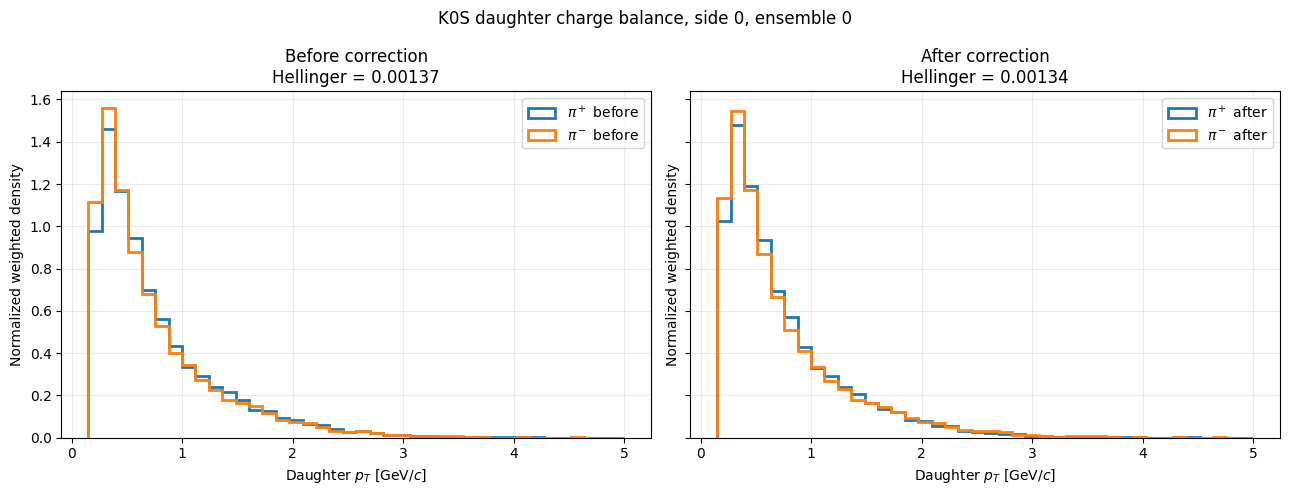

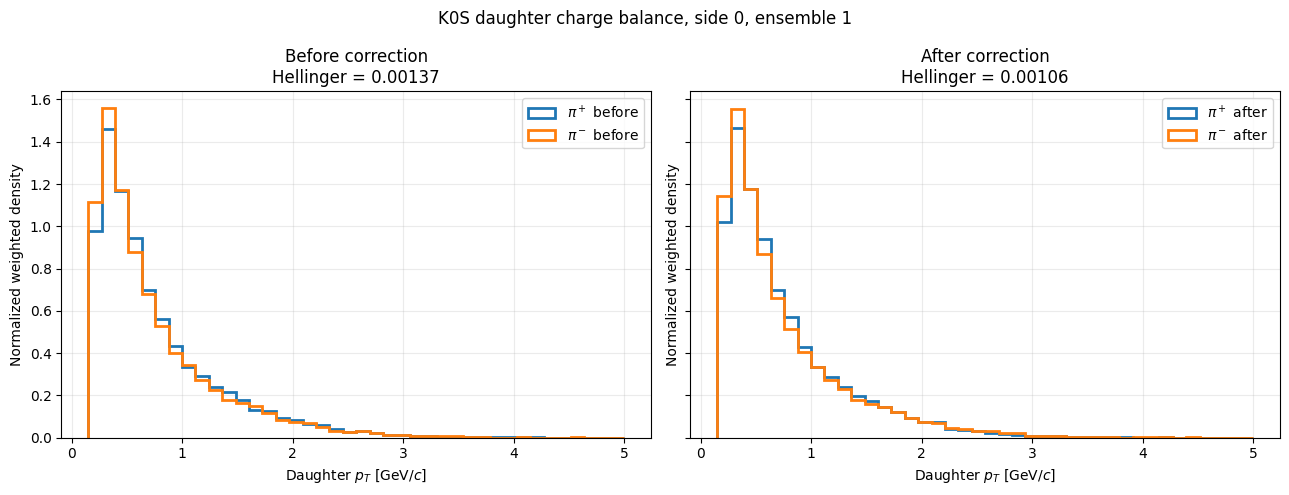

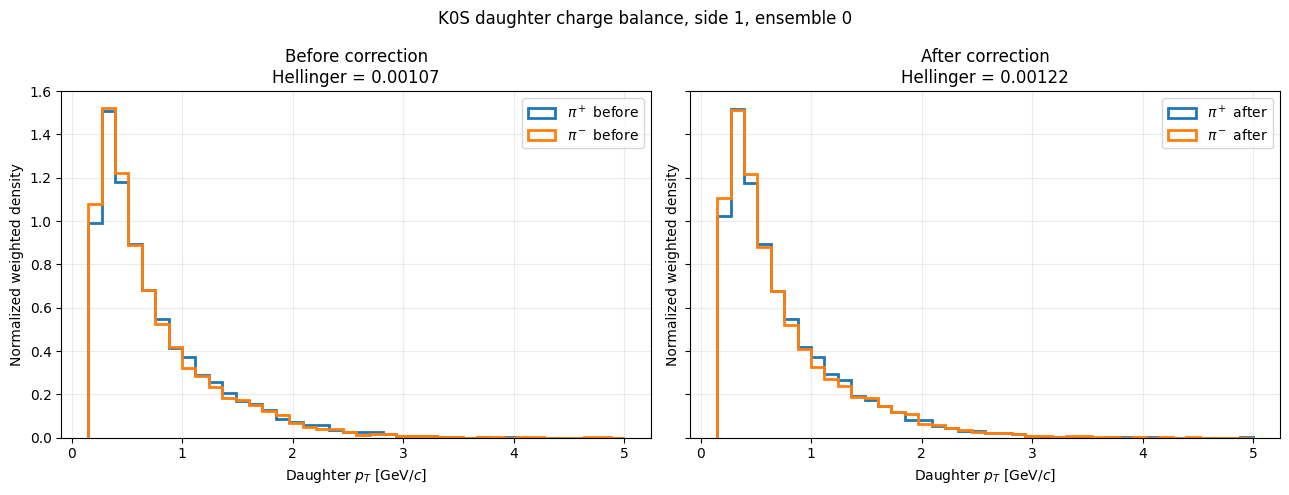

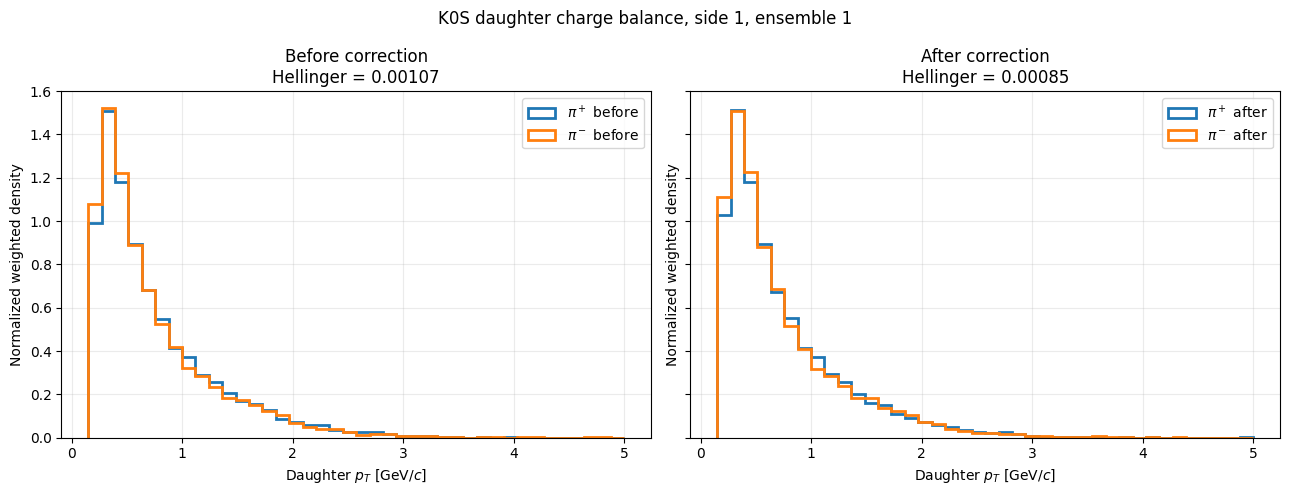

,side,ensemble_index,charge_balance_before,charge_balance_after,positive_mean_pt_before,negative_mean_pt_before,positive_mean_pt_after,negative_mean_pt_after
0,0,0,0.001373,0.001337,0.765942,0.741628,0.747704,0.749729
1,0,1,0.001373,0.001058,0.765942,0.741628,0.751777,0.744875
2,1,0,0.001069,0.001220,0.757263,0.742265,0.747570,0.743071
3,1,1,0.001069,0.000850,0.757263,0.742265,0.747286,0.742671


In [18]:
# ============================================================
# Charge-separated daughter-pT validation QA
# ============================================================

charge_balance_validation_rows = []

for side in [0, 1]:
    arrays = kshort_arrays[side]

    validation_indices = np.flatnonzero(
        arrays['event_parity'].astype(int)
        == validation_parity
    )

    validation_loader = DataLoader(
        CandidateDataset(arrays, validation_indices),
        batch_size=min(
            validation_batch_size,
            len(validation_indices),
        ),
        shuffle=False,
        num_workers=0,
        drop_last=False,
    )

    for ensemble_index, model in enumerate(trained_models[side]):
        metrics = evaluate_model(
            model,
            validation_loader,
            side,
            channel=0,
        )

        charge_balance_validation_rows.append({
            'side': side,
            'ensemble_index': ensemble_index,
            'charge_balance_before': (
                metrics['charge_balance_before']
            ),
            'charge_balance_after': (
                metrics['charge_balance_after']
            ),
            'positive_mean_pt_before': (
                metrics['positive_mean_pt_before']
            ),
            'negative_mean_pt_before': (
                metrics['negative_mean_pt_before']
            ),
            'positive_mean_pt_after': (
                metrics['positive_mean_pt_after']
            ),
            'negative_mean_pt_after': (
                metrics['negative_mean_pt_after']
            ),
        })

        figure, axes = plt.subplots(
            1,
            2,
            figsize=(13, 5),
            sharey=True,
        )

        histogram_edges = np.linspace(
            charge_balance_pt_minimum_gev,
            charge_balance_pt_maximum_gev,
            charge_balance_number_of_bins + 1,
        )

        axes[0].hist(
            metrics['positive_pt_before'],
            bins=histogram_edges,
            weights=metrics['charge_weights'],
            density=True,
            histtype='step',
            linewidth=2,
            label=r'$\pi^+$ before',
        )

        axes[0].hist(
            metrics['negative_pt_before'],
            bins=histogram_edges,
            weights=metrics['charge_weights'],
            density=True,
            histtype='step',
            linewidth=2,
            label=r'$\pi^-$ before',
        )

        axes[1].hist(
            metrics['positive_pt_after'],
            bins=histogram_edges,
            weights=metrics['charge_weights'],
            density=True,
            histtype='step',
            linewidth=2,
            label=r'$\pi^+$ after',
        )

        axes[1].hist(
            metrics['negative_pt_after'],
            bins=histogram_edges,
            weights=metrics['charge_weights'],
            density=True,
            histtype='step',
            linewidth=2,
            label=r'$\pi^-$ after',
        )

        axes[0].set_title(
            'Before correction\n'
            f"Hellinger = {metrics['charge_balance_before']:.5f}"
        )

        axes[1].set_title(
            'After correction\n'
            f"Hellinger = {metrics['charge_balance_after']:.5f}"
        )

        for axis in axes:
            axis.set_xlabel(r'Daughter $p_T$ [GeV/$c$]')
            axis.set_ylabel('Normalized weighted density')
            axis.legend()
            axis.grid(alpha=0.25)

        figure.suptitle(
            f'K0S daughter charge balance, side {side}, '
            f'ensemble {ensemble_index}'
        )

        figure.tight_layout()

        figure.savefig(
            work_dir
            / (
                f'charge_balance_side{side}_'
                f'ensemble{ensemble_index}.pdf'
            )
        )

        plt.show()

charge_balance_validation_frame = pd.DataFrame(
    charge_balance_validation_rows
)

charge_balance_validation_frame.to_csv(
    work_dir / 'charge_balance_validation.csv',
    index=False,
)

display(charge_balance_validation_frame)


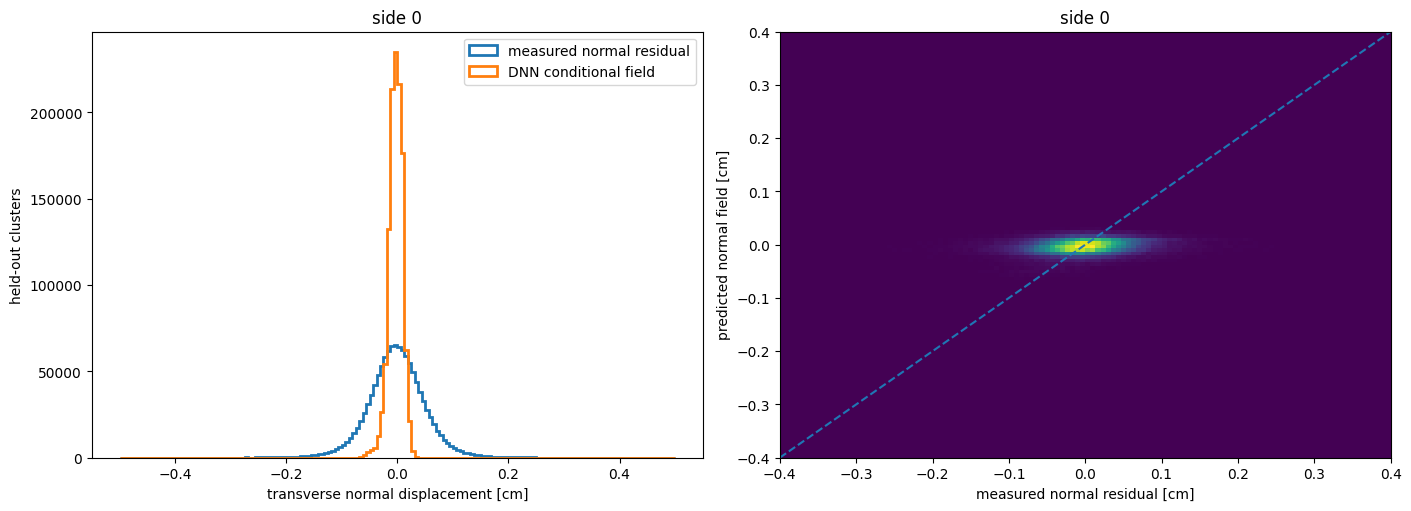

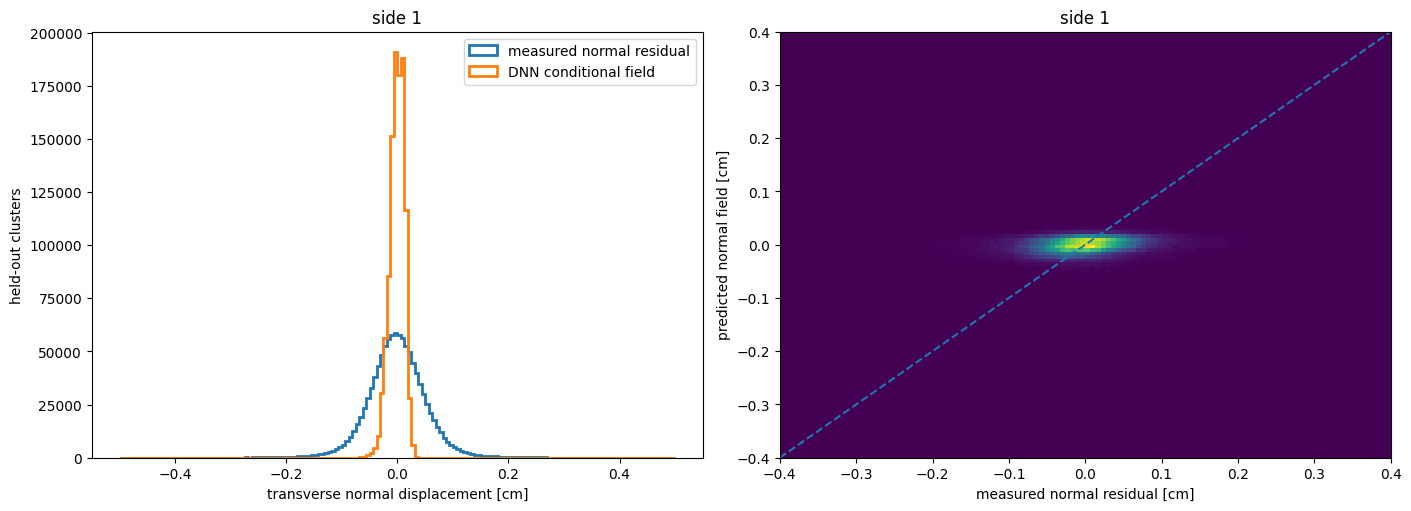

,side,clusters,target_mean,prediction_mean,rmse,correlation
0,0,1169908,-0.001839,-0.003446,0.065728,0.145196
1,1,1052580,-0.001390,-0.001177,0.064544,0.146695


In [19]:
# ============================================================
# Held-out residual-prediction QA
# ============================================================

residual_qa_rows = []

for side in [0, 1]:
    arrays = kshort_arrays[side]
    validation_indices = np.flatnonzero(
        arrays['event_parity'].astype(int)
        == validation_parity
    )

    flat = flatten_training_clusters(
        arrays,
        validation_indices,
    )

    model = ensemble_models[side]

    prediction_chunks = []
    chunk_size = 200000

    with torch.no_grad():
        for start in range(0, len(flat['r']), chunk_size):
            stop = min(start + chunk_size, len(flat['r']))

            r_tensor = torch.from_numpy(flat['r'][start:stop])
            phi_tensor = torch.from_numpy(flat['phi'][start:stop])
            z_tensor = torch.from_numpy(flat['z'][start:stop])

            delta_r, r_delta_phi, delta_z = model(
                r_tensor,
                phi_tensor,
                z_tensor,
            )

            predicted_normal = (
                delta_r.numpy()
                * flat['normal_projection_r'][start:stop]
                + r_delta_phi.numpy()
                * flat['normal_projection_rphi'][start:stop]
            )

            prediction_chunks.append(predicted_normal)

    predicted_normal = np.concatenate(prediction_chunks)
    target_normal = flat['res_normal']

    residual_qa_rows.append({
        'side': side,
        'clusters': len(target_normal),
        'target_mean': float(np.mean(target_normal)),
        'prediction_mean': float(np.mean(predicted_normal)),
        'rmse': float(np.sqrt(np.mean((predicted_normal - target_normal) ** 2))),
        'correlation': float(np.corrcoef(predicted_normal, target_normal)[0, 1]),
    })

    figure, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    axes[0].hist(
        target_normal,
        bins=160,
        range=(-0.5, 0.5),
        histtype='step',
        linewidth=2,
        label='measured normal residual',
    )

    axes[0].hist(
        predicted_normal,
        bins=160,
        range=(-0.5, 0.5),
        histtype='step',
        linewidth=2,
        label='DNN conditional field',
    )

    axes[0].set_xlabel('transverse normal displacement [cm]')
    axes[0].set_ylabel('held-out clusters')
    axes[0].set_title(f'side {side}')
    axes[0].legend()

    sample_size = min(100000, len(target_normal))
    sample = np.random.default_rng(seed + side).choice(
        len(target_normal),
        size=sample_size,
        replace=False,
    )

    axes[1].hist2d(
        target_normal[sample],
        predicted_normal[sample],
        bins=120,
        range=[[-0.4, 0.4], [-0.4, 0.4]],
    )

    axes[1].plot([-0.4, 0.4], [-0.4, 0.4], linestyle='--')
    axes[1].set_xlabel('measured normal residual [cm]')
    axes[1].set_ylabel('predicted normal field [cm]')
    axes[1].set_title(f'side {side}')

    plt.show()

residual_qa_summary = pd.DataFrame(residual_qa_rows)
residual_qa_summary.to_csv(
    work_dir / 'heldout_residual_qa.csv',
    index=False,
)

display(residual_qa_summary)


side 0 inclusive before: {'mean': 0.49853912288998103, 'width': 0.010248702048305998, 'entries': 16136}
side 0 inclusive after: {'mean': 0.49618219572985317, 'width': 0.009769451239762961, 'entries': 16172}


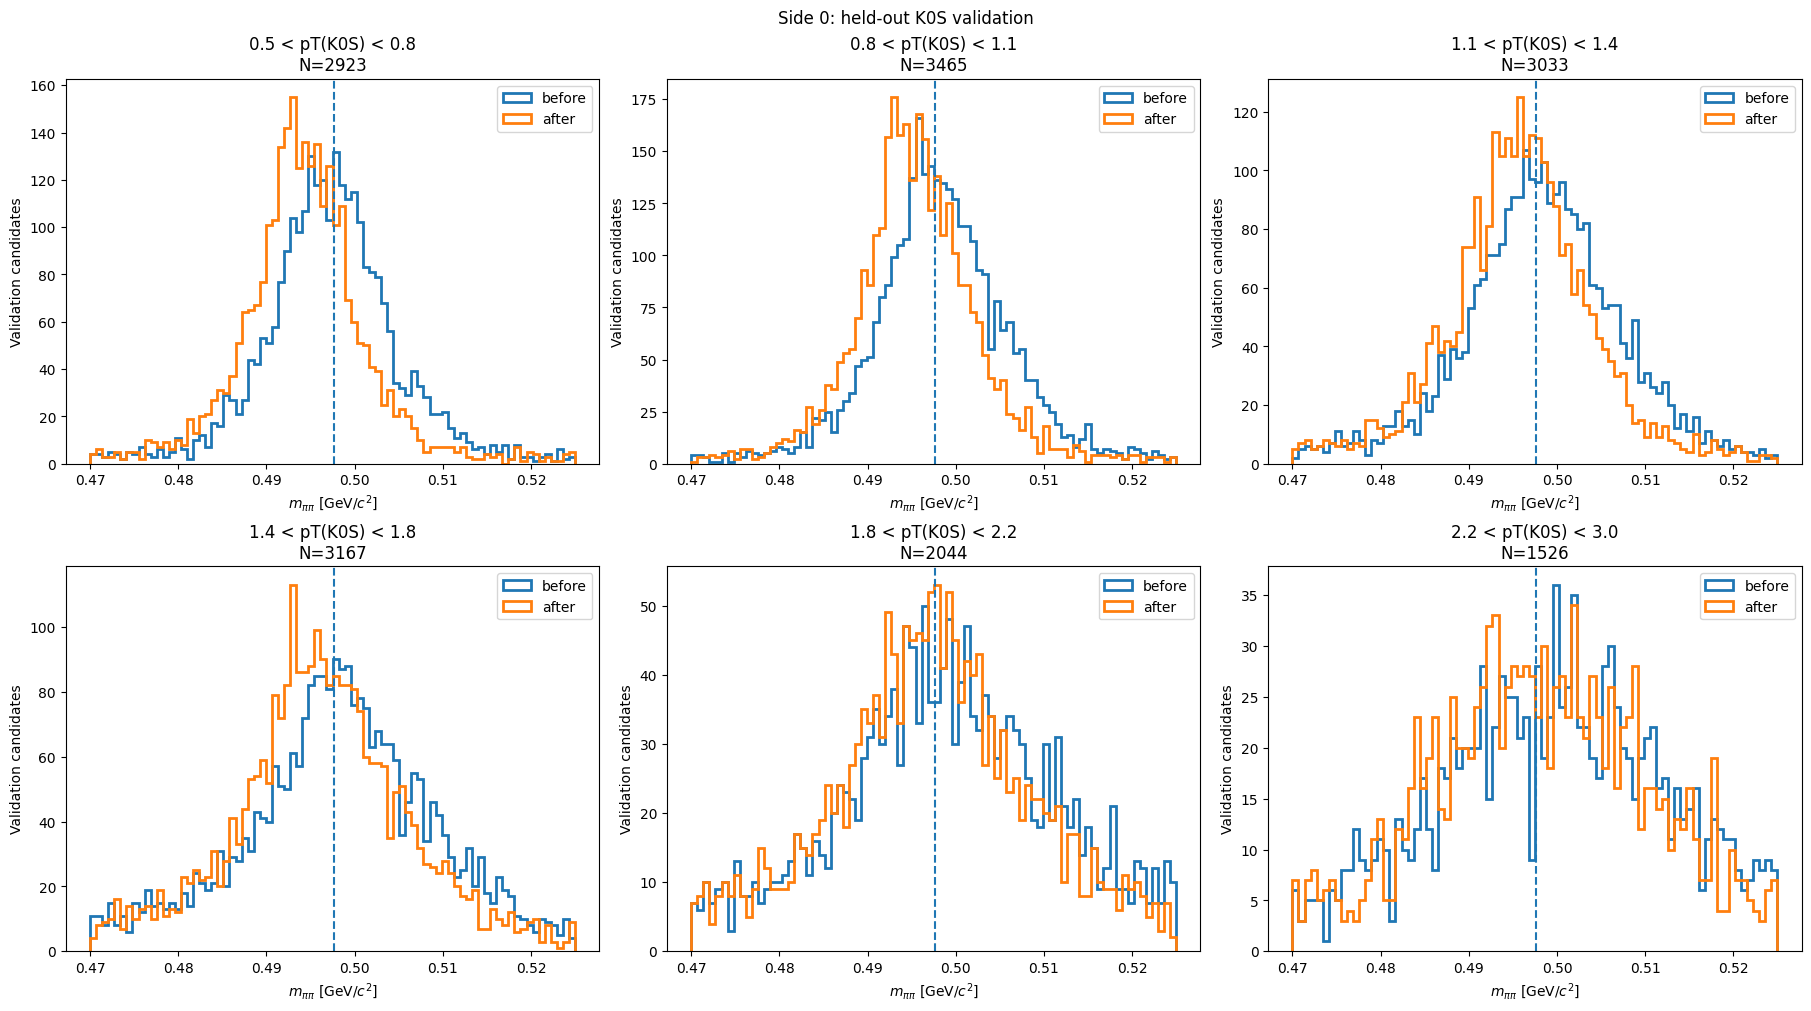

side 1 inclusive before: {'mean': 0.49851280879491616, 'width': 0.010249368140419404, 'entries': 14273}
side 1 inclusive after: {'mean': 0.4964396637764939, 'width': 0.009747162068129932, 'entries': 14353}


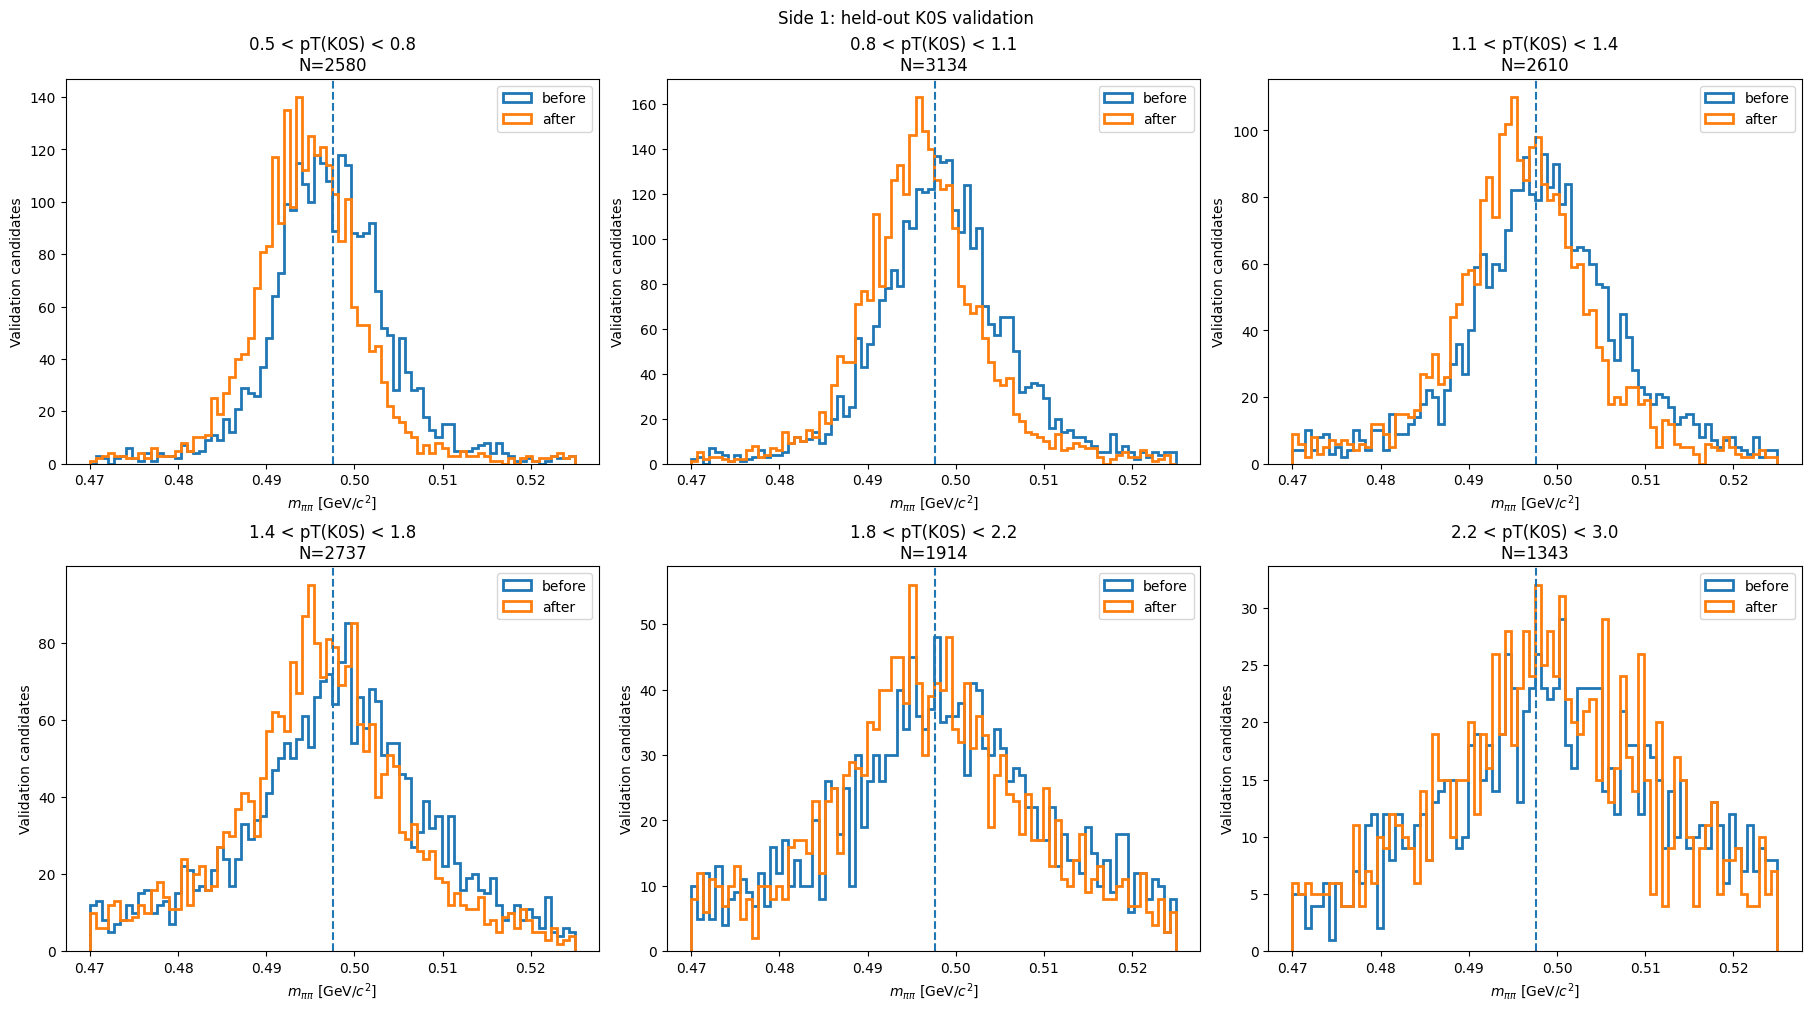

,side,pt_minimum,pt_maximum,entries,mean_before,mean_after,width_before,width_after,width_ratio
0,0,0.5,0.8,2923,0.497429,0.494453,0.008150,0.007597,0.932124
1,0,0.8,1.1,3465,0.498398,0.495676,0.008009,0.007500,0.936436
2,0,1.1,1.4,3033,0.498462,0.495942,0.009352,0.008690,0.929285
3,0,1.4,1.8,3167,0.498440,0.496538,0.011160,0.010343,0.926794
4,0,1.8,2.2,2044,0.499597,0.497931,0.012752,0.011969,0.938601
5,0,2.2,3.0,1526,0.500377,0.498929,0.013436,0.012805,0.953025
6,1,0.5,0.8,2580,0.497529,0.494972,0.007390,0.007120,0.963410
7,1,0.8,1.1,3134,0.498646,0.496294,0.008064,0.007542,0.935266
8,1,1.1,1.4,2610,0.498573,0.496305,0.009557,0.008723,0.912726
9,1,1.4,1.8,2737,0.498239,0.496303,0.011387,0.010307,0.905104


In [20]:
# ============================================================
# Held-out K0S validation, inclusive and in pT bins
# ============================================================

validation_rows = []

for side in [0, 1]:
    arrays = kshort_arrays[side]
    indices = np.flatnonzero(
        arrays['event_parity'].astype(int)
        == validation_parity
    )

    loader = DataLoader(
        CandidateDataset(arrays, indices),
        batch_size=min(validation_batch_size, len(indices)),
        shuffle=False,
    )

    metrics = evaluate_model(
        ensemble_models[side],
        loader,
        side,
        channel=0,
    )

    print(
        f'side {side} inclusive before:',
        metrics['before'],
    )
    print(
        f'side {side} inclusive after:',
        metrics['after'],
    )

    figure, axes = plt.subplots(
        2,
        3,
        figsize=(18, 10),
        constrained_layout=True,
    )

    pt_values = arrays['pair_pt'][indices]

    for bin_index, axis in enumerate(axes.flat):
        low = kshort_pt_bin_edges[bin_index]
        high = kshort_pt_bin_edges[bin_index + 1]
        select = (pt_values >= low) & (pt_values < high)

        before = metrics['mass_before'][select]
        after = metrics['mass_after'][select]

        before_metrics = peak_metrics(before)
        after_metrics = peak_metrics(after)

        validation_rows.append({
            'side': side,
            'pt_minimum': low,
            'pt_maximum': high,
            'entries': int(select.sum()),
            'mean_before': before_metrics['mean'],
            'mean_after': after_metrics['mean'],
            'width_before': before_metrics['width'],
            'width_after': after_metrics['width'],
            'width_ratio': (
                after_metrics['width'] / before_metrics['width']
                if before_metrics['width'] > 0
                else np.nan
            ),
        })

        axis.hist(
            before,
            bins=80,
            range=(0.47, 0.525),
            histtype='step',
            linewidth=2,
            label='before',
        )

        axis.hist(
            after,
            bins=80,
            range=(0.47, 0.525),
            histtype='step',
            linewidth=2,
            label='after',
        )

        axis.axvline(pdg_kshort_mass, linestyle='--')
        axis.set_title(
            f'{low:.1f} < pT(K0S) < {high:.1f}\nN={select.sum()}'
        )
        axis.set_xlabel(r'$m_{\pi\pi}$ [GeV/$c^2$]')
        axis.set_ylabel('Validation candidates')
        axis.legend()

    figure.suptitle(f'Side {side}: held-out K0S validation')
    figure.savefig(
        work_dir / f'k0s_validation_by_pt_side{side}.pdf'
    )
    plt.show()

validation_summary = pd.DataFrame(validation_rows)
validation_summary.to_csv(
    work_dir / 'k0s_validation_by_pt.csv',
    index=False,
)

display(validation_summary)


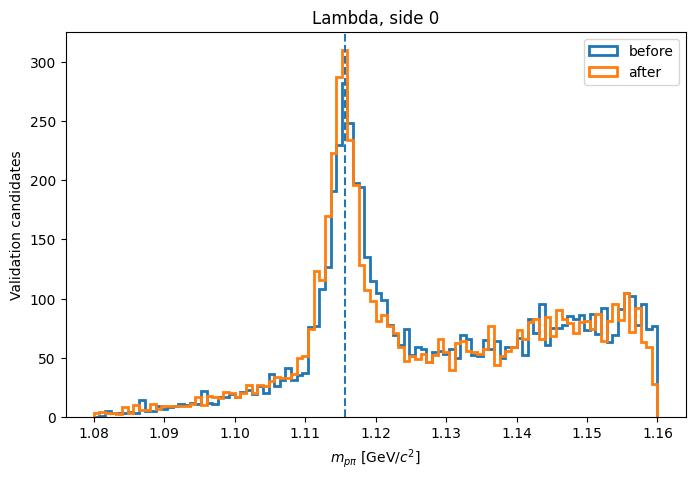

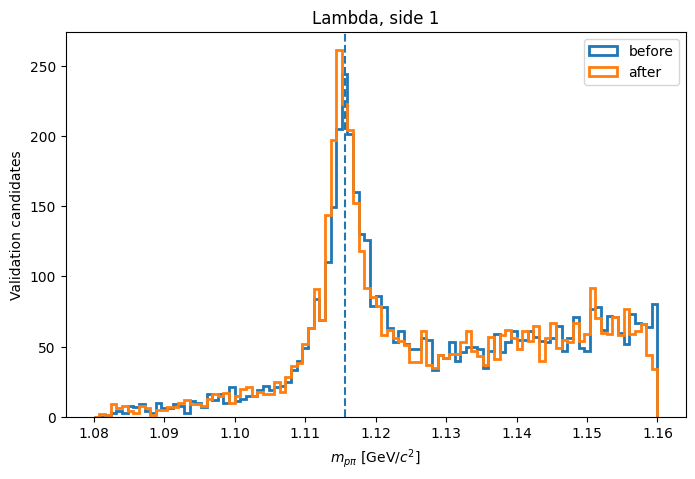

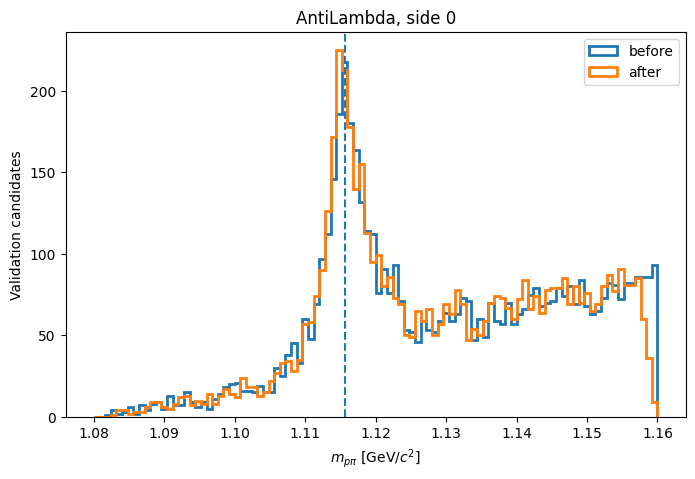

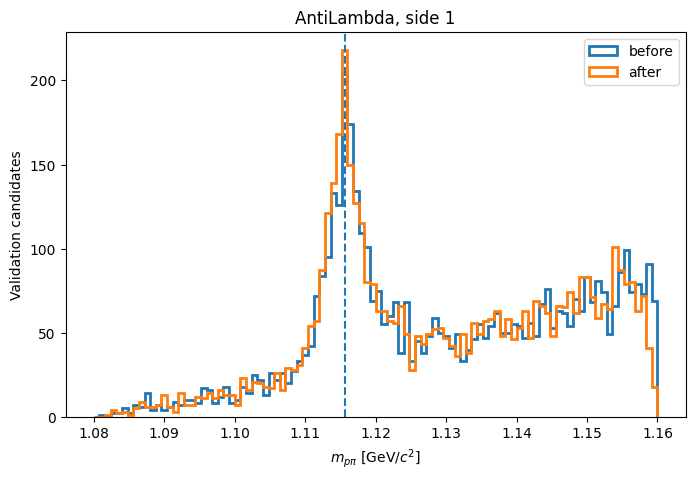

,channel,side,entries,mean_before,mean_after,width_before,width_after,width_ratio
0,Lambda,0,6115,1.119222,1.118660,0.010033,0.010118,1.008431
1,Lambda,1,4966,1.119334,1.119052,0.010075,0.010189,1.011315
2,AntiLambda,0,5588,1.120059,1.120181,0.010348,0.010321,0.997441
3,AntiLambda,1,4791,1.119676,1.119641,0.010606,0.010580,0.997481


In [21]:
# ============================================================
# Lambda and anti-Lambda validation only
# ============================================================

lambda_rows = []

for channel, label in [(1, 'Lambda'), (2, 'AntiLambda')]:
    for side in [0, 1]:
        key = (channel, side)

        if key not in validation_arrays:
            continue

        arrays = validation_arrays[key]
        indices = np.flatnonzero(
            arrays['event_parity'].astype(int)
            == validation_parity
        )

        if len(indices) == 0:
            continue

        loader = DataLoader(
            CandidateDataset(arrays, indices),
            batch_size=min(validation_batch_size, len(indices)),
            shuffle=False,
        )

        metrics = evaluate_model(
            ensemble_models[side],
            loader,
            side,
            channel=channel,
        )

        lambda_rows.append({
            'channel': label,
            'side': side,
            'entries': len(indices),
            'mean_before': metrics['before']['mean'],
            'mean_after': metrics['after']['mean'],
            'width_before': metrics['before']['width'],
            'width_after': metrics['after']['width'],
            'width_ratio': metrics['width_ratio'],
        })

        plt.figure(figsize=(8, 5))
        plt.hist(
            metrics['mass_before'],
            bins=100,
            range=(1.08, 1.16),
            histtype='step',
            linewidth=2,
            label='before',
        )
        plt.hist(
            metrics['mass_after'],
            bins=100,
            range=(1.08, 1.16),
            histtype='step',
            linewidth=2,
            label='after',
        )
        plt.axvline(1.115683, linestyle='--')
        plt.xlabel(r'$m_{p\pi}$ [GeV/$c^2$]')
        plt.ylabel('Validation candidates')
        plt.title(f'{label}, side {side}')
        plt.legend()
        plt.savefig(
            work_dir / f'{label.lower()}_validation_side{side}.pdf'
        )
        plt.show()

lambda_summary = pd.DataFrame(lambda_rows)
lambda_summary.to_csv(
    work_dir / 'lambda_validation.csv',
    index=False,
)

display(lambda_summary)


## Export the physical detector-space map

Each side histogram retains the full signed-\(z\) axis for compatibility, but the model returns zero outside that side's physical domain.

The exported map contains the sum of:

- the smooth drift-dependent DNN correction;
- the fitted side-level pad-plane offset and tilt-like field;
- the fitted local module displacement.

The QA panels include the pad-plane endpoint, where transverse corrections are now allowed to be nonzero while \(\Delta z\) remains zero.


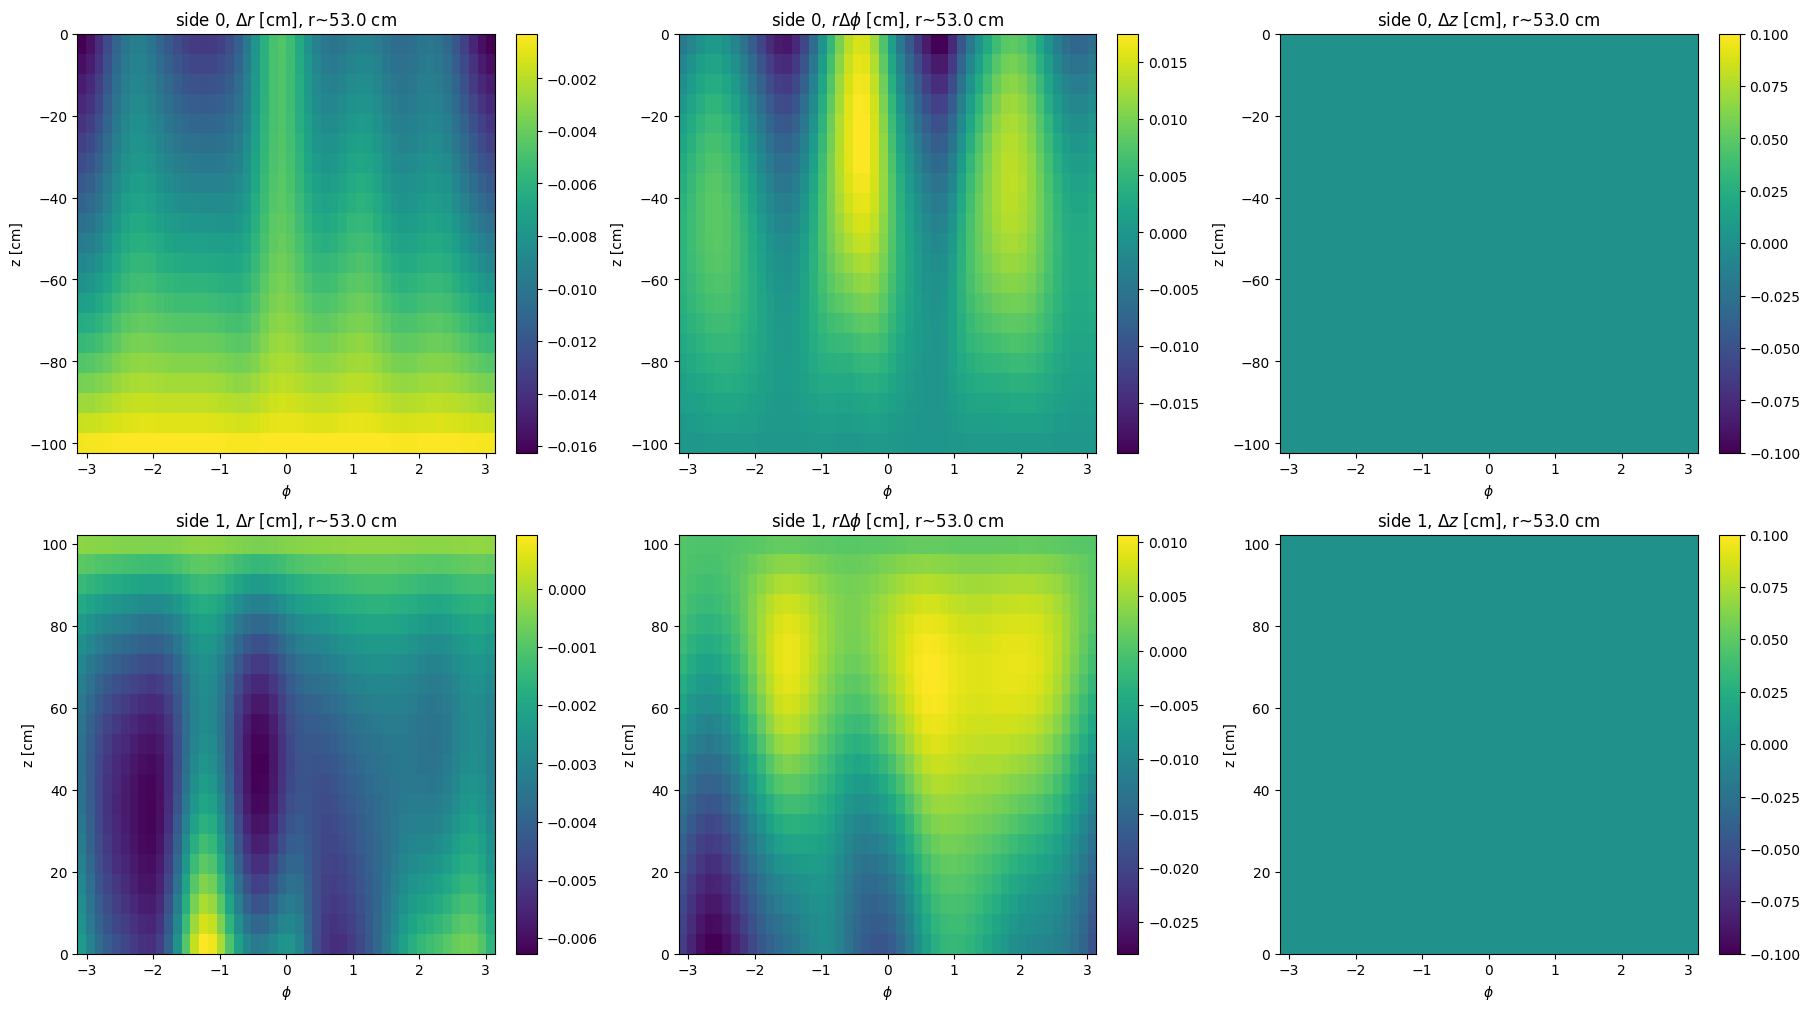

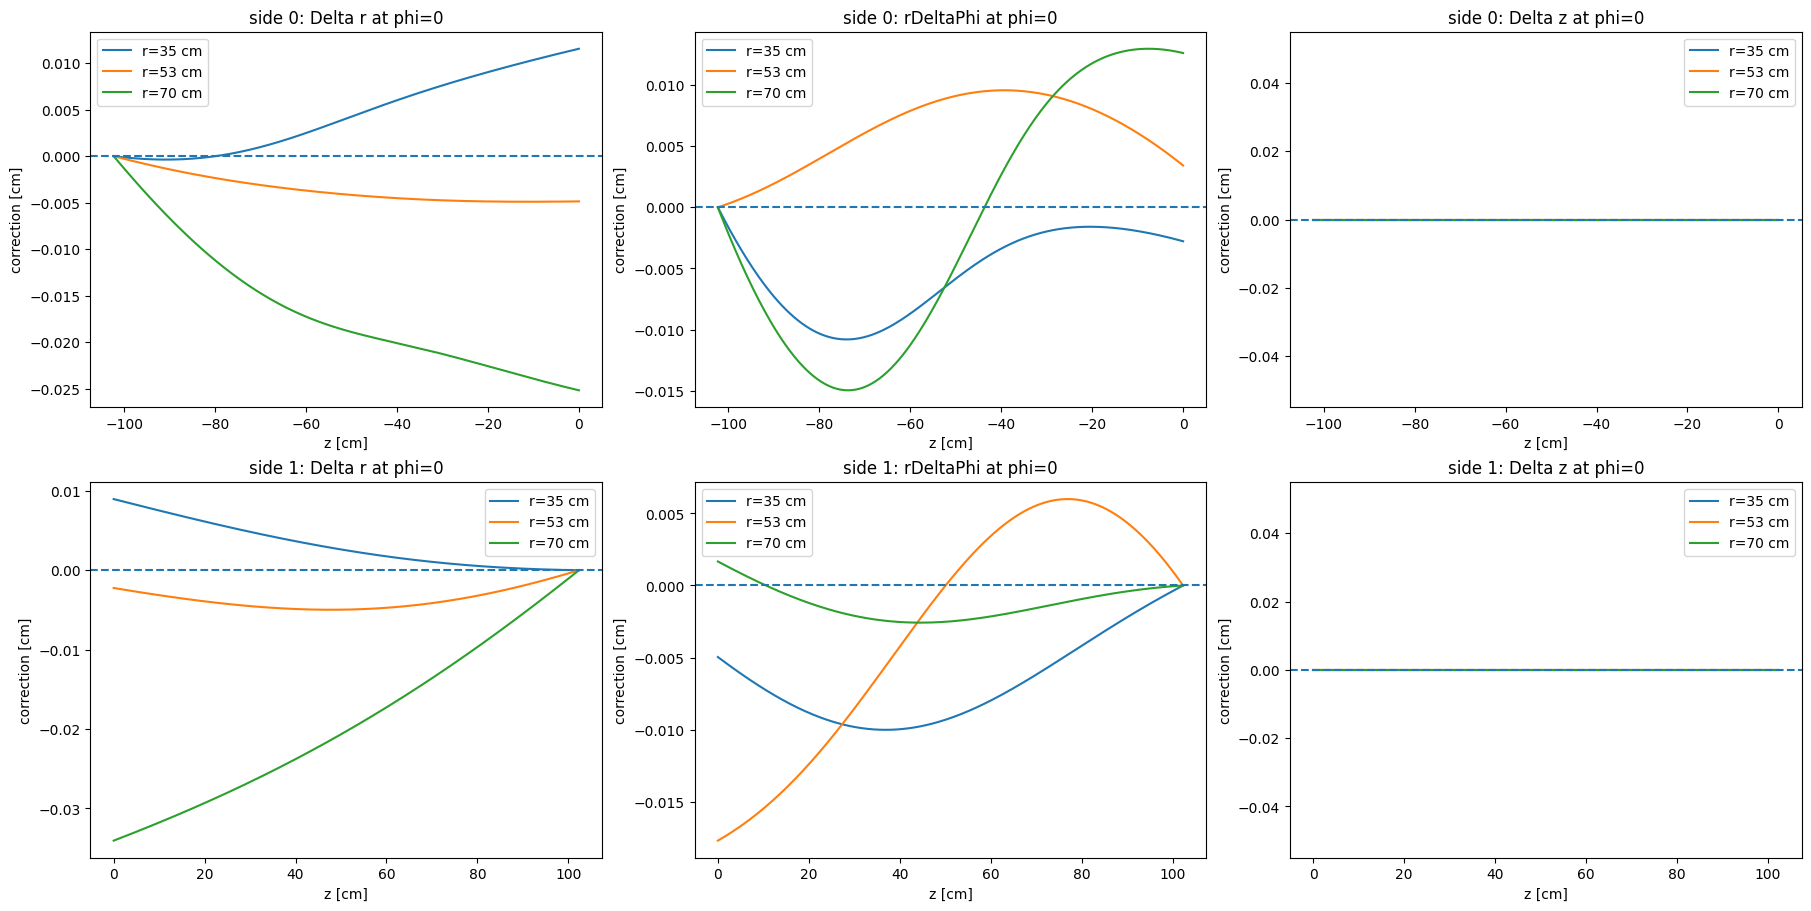

Wrote: output/v0_spatial_residual_dnn_new_v3_conservative/v0_spatial_map_transverse_only_conservative.root


In [22]:
# ============================================================
# Spatial-map QA and ROOT export
# ============================================================

r_edges = np.linspace(30.5, 76.5, 47)
phi_edges = np.linspace(-math.pi, math.pi, 49)
z_edges = np.linspace(-z_pad_cm, z_pad_cm, 43)

r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
phi_centers = 0.5 * (phi_edges[:-1] + phi_edges[1:])
z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])

map_rows = []

for side in [0, 1]:
    r_grid, phi_grid, z_grid = np.meshgrid(
        r_centers,
        phi_centers,
        z_centers,
        indexing='ij',
    )

    with torch.no_grad():
        delta_r, r_delta_phi, delta_z = ensemble_models[side](
            torch.from_numpy(r_grid.astype(np.float32)),
            torch.from_numpy(phi_grid.astype(np.float32)),
            torch.from_numpy(z_grid.astype(np.float32)),
        )

    for (
        radius_value,
        phi_value,
        z_value,
        delta_r_value,
        r_delta_phi_value,
        delta_z_value,
    ) in zip(
        r_grid.ravel(),
        phi_grid.ravel(),
        z_grid.ravel(),
        delta_r.numpy().ravel(),
        r_delta_phi.numpy().ravel(),
        delta_z.numpy().ravel(),
    ):
        map_rows.append({
            'side': side,
            'r': radius_value,
            'phi': phi_value,
            'z': z_value,
            'delta_r': delta_r_value,
            'rdelta_phi': r_delta_phi_value,
            'delta_z': delta_z_value,
        })

map_frame = pd.DataFrame(map_rows)
map_frame.to_csv(
    work_dir / 'v0_spatial_residual_map_grid.csv',
    index=False,
)

# Physical phi-z slices near r=53 cm.
figure, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10),
    constrained_layout=True,
)

selected_radius = r_centers[
    np.argmin(np.abs(r_centers - 53.0))
]

for side in [0, 1]:
    if side == 0:
        physical_z_selection = map_frame['z'] <= 0.0
    else:
        physical_z_selection = map_frame['z'] >= 0.0

    subset = map_frame.loc[
        (map_frame['side'] == side)
        & np.isclose(map_frame['r'], selected_radius)
        & physical_z_selection
    ]

    for column_index, (column, title) in enumerate([
        ('delta_r', r'$\Delta r$ [cm]'),
        ('rdelta_phi', r'$r\Delta\phi$ [cm]'),
        ('delta_z', r'$\Delta z$ [cm]'),
    ]):
        values = subset.pivot(
            index='z',
            columns='phi',
            values=column,
        )

        image = axes[side, column_index].pcolormesh(
            values.columns,
            values.index,
            values.values,
            shading='auto',
        )

        axes[side, column_index].set_xlabel(r'$\phi$')
        axes[side, column_index].set_ylabel('z [cm]')
        axes[side, column_index].set_title(
            f'side {side}, {title}, r~{selected_radius:.1f} cm'
        )

        figure.colorbar(
            image,
            ax=axes[side, column_index],
        )

plt.show()

# Explicit z profiles showing the nonzero transverse pad-plane endpoint.
figure, axes = plt.subplots(
    2,
    3,
    figsize=(18, 9),
    constrained_layout=True,
)

profile_phi = 0.0
profile_radii = [35.0, 53.0, 70.0]

for side in [0, 1]:
    z_profile = (
        np.linspace(-z_pad_cm, 0.0, 240)
        if side == 0
        else np.linspace(0.0, z_pad_cm, 240)
    )

    for radius_value in profile_radii:
        with torch.no_grad():
            delta_r, r_delta_phi, delta_z = ensemble_models[side](
                torch.full((len(z_profile),), radius_value),
                torch.full((len(z_profile),), profile_phi),
                torch.from_numpy(z_profile.astype(np.float32)),
            )

        axes[side, 0].plot(
            z_profile,
            delta_r.numpy(),
            label=f'r={radius_value:.0f} cm',
        )

        axes[side, 1].plot(
            z_profile,
            r_delta_phi.numpy(),
            label=f'r={radius_value:.0f} cm',
        )

        axes[side, 2].plot(
            z_profile,
            delta_z.numpy(),
            label=f'r={radius_value:.0f} cm',
        )

    axes[side, 0].set_title(f'side {side}: Delta r at phi=0')
    axes[side, 1].set_title(f'side {side}: rDeltaPhi at phi=0')
    axes[side, 2].set_title(f'side {side}: Delta z at phi=0')

    for axis in axes[side]:
        axis.axhline(0.0, linestyle='--')
        axis.set_xlabel('z [cm]')
        axis.set_ylabel('correction [cm]')
        axis.legend()

plt.show()

root_file = work_dir / (
    f'v0_spatial_map_with_z_{geometry_profile_name}.root'
    if include_z_correction
    else f'v0_spatial_map_transverse_only_{geometry_profile_name}.root'
)

if root is None:
    print('PyROOT unavailable; ROOT map not written')
else:
    output = root.TFile.Open(str(root_file), 'RECREATE')

    root.TNamed(
        'residual_convention',
        'map is measured-minus-fit field; apply corrected cluster = measured - map',
    ).Write()

    root.TNamed(
        'transverse_training_constraint',
        'normal projection: dn = delta_r*(n.er) + rdelta_phi*(n.ephi)',
    ).Write()

    root.TNamed(
        'pad_plane_boundary',
        (
            f'transverse side/module alignment may be nonzero at '
            f'abs(z)={z_pad_cm} cm; Delta z remains zero'
        ),
    ).Write()

    root.TNamed(
        'geometry_profile',
        geometry_profile_name,
    ).Write()

    root.TNamed(
        'geometry_limits_cm',
        json.dumps({
            'maximum_side_offset_cm': maximum_side_offset_cm,
            'maximum_side_tilt_displacement_cm': (
                maximum_side_tilt_displacement_cm
            ),
            'maximum_module_offset_cm': maximum_module_offset_cm,
            'minimum_tpc_modules_per_track': (
                minimum_tpc_modules_per_track
            ),
        }),
    ).Write()

    root.TNamed(
        'include_z_correction',
        str(int(include_z_correction)),
    ).Write()

    for side in [0, 1]:
        directory = output.mkdir(f'side{side}')
        directory.cd()

        histograms = {
            'h3_delta_r': root.TH3D(
                'h3_delta_r',
                'Delta r;r [cm];#phi;z [cm]',
                len(r_edges) - 1,
                array('d', r_edges),
                len(phi_edges) - 1,
                array('d', phi_edges),
                len(z_edges) - 1,
                array('d', z_edges),
            ),
            'h3_rdelta_phi': root.TH3D(
                'h3_rdelta_phi',
                'rDeltaPhi;r [cm];#phi;z [cm]',
                len(r_edges) - 1,
                array('d', r_edges),
                len(phi_edges) - 1,
                array('d', phi_edges),
                len(z_edges) - 1,
                array('d', z_edges),
            ),
            'h3_delta_z': root.TH3D(
                'h3_delta_z',
                'Delta z;r [cm];#phi;z [cm]',
                len(r_edges) - 1,
                array('d', r_edges),
                len(phi_edges) - 1,
                array('d', phi_edges),
                len(z_edges) - 1,
                array('d', z_edges),
            ),
        }

        subset = map_frame.loc[
            map_frame['side'] == side
        ]

        for row in subset.itertuples(index=False):
            for name, column in [
                ('h3_delta_r', 'delta_r'),
                ('h3_rdelta_phi', 'rdelta_phi'),
                ('h3_delta_z', 'delta_z'),
            ]:
                histogram = histograms[name]
                histogram.SetBinContent(
                    histogram.FindBin(row.r, row.phi, row.z),
                    getattr(row, column),
                )

        for histogram in histograms.values():
            histogram.Write()

    output.Close()
    print('Wrote:', root_file)


## Applying the map before the Kalman fit

For a cluster at \((r,\phi,z)\), look up the side-specific measured-minus-fit field and apply

\[
r_{\rm corr}=r-\Delta r,
\qquad
\phi_{\rm corr}=\phi-\frac{r\Delta\phi}{r},
\qquad
z_{\rm corr}=z-\Delta z.
\]

Then construct corrected \((x,y,z)\) measurements and run the Kalman fit. Do not apply the earlier post-fit momentum-scale or sagitta correction afterward.


## Running conservative and wide geometry fits in parallel

Create two notebook copies or launch the notebook twice with different configuration values:

```python
geometry_profile_name = 'conservative'
```

and

```python
geometry_profile_name = 'wide'
```

The outputs are isolated automatically:

```text
output/v0_spatial_residual_dnn_v8_conservative/
output/v0_spatial_residual_dnn_v8_wide/
```

A useful first comparison grid is:

| Run | Profile | Minimum modules | Minimum radial span |
|---|---|---:|---:|
| A | conservative | 2 | 15 cm |
| B | wide | 2 | 15 cm |
| C | conservative | 3 | 15 cm |
| D | wide | 3 | 15 cm |

For a lighter first pass, run only A and B. Compare held-out normal residuals, \(K^0_S\) mass width, side-level parameters, per-module RMS, and residuals near module boundaries before selecting the final geometry range.
